# QAPINN: Quantum-Assisted Physics-Informed Neural Networks for Burgers' Equation

### BQP WISER Global Quantum+AI 2026

This notebook provides a comprehensive investigation into **Quantum-Assisted Physics-Informed Neural Networks (QAPINN)**. We evaluate a hybrid model where a portion of a classical Physics-Informed Neural Network (PINN) is replaced by a **Variational Quantum Circuit (VQC)**.

**Objective:** To rigorously analyze when, why, and how quantum layers affect the learning dynamics of the **1D viscous Burgers' equation**:
$$u_t + u\,u_x = \nu\,u_{xx}, \qquad \nu = 0.01/\pi$$

**Methodology:**
* **Hybrid Execution:** Classical layers run on **GPU (CUDA)** while the quantum simulation is handled by **PennyLane (JAX backend)** on the CPU.
* **Explainability (XAI):** We utilize Fourier spectrum analysis, gradient variance scans (McClean-style), and activation mapping to diagnose the model's internal behavior.
* **Benchmarking:** Models are validated against the **Cole-Hopf analytical solution** to ensure ground-truth accuracy beyond simple training loss.

### Step 1: Environment Setup and GPU Verification

In this section, we install the necessary libraries (`pennylane`, `jax`) and establish a reproducible environment by setting global seeds for NumPy, PyTorch, and JAX. We also perform a hardware check to confirm the availability of CUDA for the classical components and initialize the CPU-based quantum simulator.

In [ ]:
!pip install pennylane "jax==0.9.2" "jaxlib==0.9.2"

# ============================================================
# Setup, GPU check, reproducibility
# ============================================================
import time
import math
import random
import numpy as np
import torch
import torch.nn as nn
import pennylane as qp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import jax
import jax.numpy as jnp

# The quantum circuit is simulated with PennyLane's JAX interface (JIT-compiled,
# see the new "JAX <-> PyTorch bridge" cell below) instead of the torch interface.
# jax/jaxlib are pinned to 0.9.2: PennyLane's JAX interface (as of this notebook's
# PennyLane version) calls `jax.core.is_concrete`, which JAX deprecated in 0.10 and
# removed in 0.11 -- newer jax/jaxlib raise an AttributeError at qnode call time.
jax.config.update("jax_platform_name", "cpu")  # quantum device stays CPU-only, as before

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

sns.set_theme(style="whitegrid", palette="viridis")

GPU_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if GPU_DEVICE == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("No GPU found. Runtime -> Change runtime type -> GPU, then re-run this cell.")

print(f"\nPyTorch : {torch.__version__}")
print(f"PennyLane: {qp.__version__}")
print(f"JAX      : {jax.__version__}  (quantum circuit backend)")
print(f"Device for classical layers: {GPU_DEVICE.upper()}")
print("Quantum circuit device: CPU (default.qubit simulator, JAX interface, always)")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.3/83.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 127.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 103.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 131.7 MB/s eta 0:00:00
  Attempting uninstall: autograd
    Found existing installation: autograd 1.9.1
    Uninstalling autograd-1.9.1:
      Successfully uninstalled autograd-1.9.1
  Attempting uninstall: jaxlib
    Found existing i

/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.9.2, so it will not be used.
  warnings.warn(


GPU: Tesla T4
GPU Memory: 15.64 GB

PyTorch : 2.11.0+cu128
PennyLane: 0.45.1
JAX      : 0.9.2  (quantum circuit backend)
Device for classical layers: CUDA
Quantum circuit device: CPU (default.qubit simulator, JAX interface, always)


**Reading the output:** confirm the printout shows `GPU: Tesla T4` (or whatever GPU Colab assigned) and
`Device for classical layers: CUDA`. If it instead prints *"No GPU found"*, go to
**Runtime → Change runtime type → GPU** and re-run this cell before continuing.

### Step 2: PDE Configuration and Physics Utilities

Here we define the governing physics of the **1D Viscous Burgers' Equation**. This includes setting the viscosity parameter ($\nu$), defining the spatial and temporal domains, and creating sampling functions for collocation, initial, and boundary points. The `burgers_residual` function utilizes PyTorch autograd to compute the PDE loss.

In [ ]:
# ============================================================
# Physics: 1D viscous Burgers' equation
#   u_t + u*u_x = nu * u_xx ,  nu = 0.01/pi
#   u(x,0) = -sin(pi x)                      (initial condition)
#   u(-1,t) = u(1,t) = 0                     (Dirichlet boundary)
# ============================================================
PHYSICS_CONFIG = {
    "nu": 0.01 / np.pi,
    "x_min": -1.0, "x_max": 1.0,
    "t_min": 0.0, "t_max": 1.0,
    "n_collocation": 2000,
    "n_initial": 200,
    "n_boundary": 200,
}
LOSS_WEIGHTS = {"pde": 1.0, "ic": 1.0, "bc": 1.0}


def sample_collocation(n=None, device="cpu"):
    n = n or PHYSICS_CONFIG["n_collocation"]
    x = torch.empty(n, 1, device=device).uniform_(PHYSICS_CONFIG["x_min"], PHYSICS_CONFIG["x_max"])
    t = torch.empty(n, 1, device=device).uniform_(PHYSICS_CONFIG["t_min"], PHYSICS_CONFIG["t_max"])
    return x, t


def sample_initial(n=None, device="cpu"):
    n = n or PHYSICS_CONFIG["n_initial"]
    x = torch.empty(n, 1, device=device).uniform_(PHYSICS_CONFIG["x_min"], PHYSICS_CONFIG["x_max"])
    t = torch.zeros(n, 1, device=device)
    u0 = -torch.sin(np.pi * x)
    return x, t, u0


def sample_boundary(n=None, device="cpu"):
    n = n or PHYSICS_CONFIG["n_boundary"]
    t = torch.empty(n, 1, device=device).uniform_(PHYSICS_CONFIG["t_min"], PHYSICS_CONFIG["t_max"])
    x_left = torch.full((n, 1), PHYSICS_CONFIG["x_min"], device=device)
    x_right = torch.full((n, 1), PHYSICS_CONFIG["x_max"], device=device)
    u_b = torch.zeros(n, 1, device=device)
    return x_left, x_right, t, u_b


def burgers_residual(model, x, t):
    nu = PHYSICS_CONFIG["nu"]
    x = x.clone().requires_grad_(True)
    t = t.clone().requires_grad_(True)
    u = model(x, t)
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    return u_t + u * u_x - nu * u_xx


def compute_losses(model, device="cpu"):
    x_f, t_f = sample_collocation(device=device)
    residual = burgers_residual(model, x_f, t_f)
    loss_pde = torch.mean(residual ** 2)

    x0, t0, u0 = sample_initial(device=device)
    loss_ic = torch.mean((model(x0, t0) - u0) ** 2)

    xl, xr, tb, ub = sample_boundary(device=device)
    loss_bc = torch.mean((model(xl, tb) - ub) ** 2) + torch.mean((model(xr, tb) - ub) ** 2)

    total = LOSS_WEIGHTS["pde"] * loss_pde + LOSS_WEIGHTS["ic"] * loss_ic + LOSS_WEIGHTS["bc"] * loss_bc
    return {
        "total": total, "pde": loss_pde, "ic": loss_ic, "bc": loss_bc,
        "mean_residual": residual.abs().mean(), "max_residual": residual.abs().max(),
    }

print("Physics utilities loaded.")


Physics utilities loaded.


**Reading the output:** just defines functions and prints `Physics utilities loaded.` — nothing to interpret yet.

### Step 3: High-Performance Quantum Bridge (JAX-PyTorch)

To optimize the training of hybrid models, we implement a custom **JAX <-> PyTorch bridge**. This allows the quantum circuits to benefit from JAX's JIT compilation and vectorization (`vmap`) while remaining fully compatible with PyTorch's `autograd` engine. This bridge is essential for calculating the higher-order derivatives (like $u_{xx}$) required by the PINN framework.

In [ ]:
# ============================================================
# JAX <-> PyTorch bridge for the quantum layer
# ============================================================
class _VJPChain:
    """
    Wraps a JAX primal function f(inputs, weights) -> array so it can be
    called from PyTorch with support for arbitrary-order autodiff. A PINN
    differentiates the model twice w.r.t. its inputs (for u_xx) and once
    more w.r.t. its weights when .backward() runs on the total loss --
    three nested levels of differentiation through the quantum circuit.

    Each order's JAX function is JIT-compiled once (lazily, the first time
    it's needed) and cached, so repeated forward/backward calls across
    training epochs hit XLA's compiled cache instead of re-tracing from
    scratch. Chains are cached globally per circuit architecture (see
    `_get_qapinn_chain` below), so creating new QAPINN instances with the
    same (n_qubits, n_qlayers, encoding, ansatz) -- e.g. across Stage C's
    multi-seed sweep -- reuses the already-compiled circuit rather than
    paying the compile cost again.
    """
    def __init__(self, primal_fn):
        def level0(inputs, weights):
            return (primal_fn(inputs, weights),)
        self._fns = {0: jax.jit(level0)}
        self._n_in = {0: 2}
        self._n_out = {0: 1}

    def level(self, order):
        if order not in self._fns:
            prev_fn = self.level(order - 1)
            n_in_prev = self._n_in[order - 1]
            n_out_prev = self._n_out[order - 1]

            def next_fn(*args, _prev=prev_fn, _n_in=n_in_prev, _n_out=n_out_prev):
                inputs = args[:_n_in]
                cotangents = args[_n_in:_n_in + _n_out]
                _, vjp_fn = jax.vjp(_prev, *inputs)
                return vjp_fn(cotangents)

            self._fns[order] = jax.jit(next_fn)
            self._n_in[order] = n_in_prev + n_out_prev
            self._n_out[order] = n_in_prev
        return self._fns[order]


class _JaxOp(torch.autograd.Function):
    """Generic torch<->JAX bridge: evaluates chain.level(order) on the given
    torch tensors (converting to/from JAX arrays at the boundary), and on
    backward, recurses into chain.level(order + 1) -- so the backward pass
    is itself differentiable, to whatever order the calling torch autograd
    graph actually demands."""
    @staticmethod
    def forward(ctx, chain, order, *args):
        ctx.chain = chain
        ctx.order = order
        ctx.save_for_backward(*args)
        fn = chain.level(order)
        jargs = tuple(jnp.asarray(a.detach().cpu().numpy()) for a in args)
        outs = fn(*jargs)
        outs_t = tuple(
            torch.as_tensor(np.array(o), dtype=args[i].dtype, device=args[i].device)
            for i, o in enumerate(outs)
        )
        return outs_t if len(outs_t) > 1 else outs_t[0]

    @staticmethod
    def backward(ctx, *grad_outs):
        chain, order = ctx.chain, ctx.order
        args = ctx.saved_tensors
        grads = _JaxOp.apply(chain, order + 1, *args, *grad_outs)
        if not isinstance(grads, tuple):
            grads = (grads,)
        return (None, None) + grads


class JaxQuantumLayer(nn.Module):
    """Drop-in replacement for qml.qnn.TorchLayer: same call signature
    (batched torch tensor in, torch tensor out) and the same "weights"
    parameter name/init scheme (uniform on [0, 2*pi], matching TorchLayer's
    default) -- but the QNode is built with PennyLane's JAX interface and
    executed/differentiated via JAX (JIT-compiled, vmapped over the batch
    dimension), bridged into PyTorch's autograd via _JaxOp/_VJPChain above."""
    def __init__(self, batched_primal_fn, weight_shape, chain=None):
        super().__init__()
        self.weights = nn.Parameter(torch.empty(weight_shape).uniform_(0, 2 * math.pi))
        self._chain = chain if chain is not None else _VJPChain(batched_primal_fn)

    def forward(self, inputs):
        return _JaxOp.apply(self._chain, 0, inputs, self.weights)


_QAPINN_CHAIN_CACHE = {}

def _get_qapinn_chain(n_qubits, n_qlayers, encoding, ansatz, batched_primal_fn):
    """Global cache: one compiled _VJPChain per circuit architecture, shared
    across every QAPINN instance built with that architecture (different
    seeds, different weight inits, Stage C's repeated model construction,
    etc.), so the JIT compile cost above is paid only once per architecture."""
    key = (n_qubits, n_qlayers, encoding, ansatz)
    if key not in _QAPINN_CHAIN_CACHE:
        _QAPINN_CHAIN_CACHE[key] = _VJPChain(batched_primal_fn)
    return _QAPINN_CHAIN_CACHE[key]


print("JAX<->PyTorch bridge defined: JaxQuantumLayer (drop-in replacement for qml.qnn.TorchLayer).")


JAX<->PyTorch bridge defined: JaxQuantumLayer (drop-in replacement for qml.qnn.TorchLayer).


### Step 4: Model Architectures (Classical vs. Quantum)

We define two primary model classes:
1. **ClassicalPINN:** A standard fully-connected deep neural network.
2. **QAPINN:** A hybrid model where the first hidden layer is a Variational Quantum Circuit (VQC).

The QAPINN supports multiple **encodings** (Angle, Re-uploading) and **ansatzes** (Basic Entangler, Strongly Entangling) to allow for ablation studies.

In [ ]:
# ============================================================
# Models: Classical PINN (full GPU) and QAPINN (hybrid GPU/CPU)
# ============================================================
ACTIVATIONS = {"tanh": nn.Tanh, "relu": nn.ReLU, "gelu": nn.GELU, "silu": nn.SiLU, "elu": nn.ELU}


class ClassicalPINN(nn.Module):
    """Baseline: FC 2 -> 25 -> 25 -> 25 -> 25 -> 1, runs entirely on GPU."""

    def __init__(self, layers=(2, 25, 25, 25, 25, 1), activation="tanh", initializer="xavier"):
        super().__init__()
        self.layers = layers
        act = ACTIVATIONS[activation.lower()]
        modules = []
        for i in range(len(layers) - 1):
            modules.append(nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:
                modules.append(act())
        self.net = nn.Sequential(*modules)
        self._init_weights(initializer)

    def _init_weights(self, initializer):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                if initializer == "xavier":
                    nn.init.xavier_normal_(m.weight)
                elif initializer == "kaiming":
                    nn.init.kaiming_normal_(m.weight)
                else:
                    nn.init.normal_(m.weight, 0, 0.02)
                nn.init.zeros_(m.bias)

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

    def num_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


SUPPORTED_ENCODINGS = ["angle", "reupload"]
SUPPORTED_ANSATZ = ["basic_entangler", "strongly_entangling"]


def build_qnode(n_qubits, n_layers, encoding="angle", ansatz="basic_entangler"):
    assert encoding in SUPPORTED_ENCODINGS, f"Unsupported encoding: {encoding}"
    assert ansatz in SUPPORTED_ANSATZ, f"Unsupported ansatz: {ansatz}"
    dev = qp.device("default.qubit", wires=n_qubits)

    def apply_ansatz(weights):
        if ansatz == "basic_entangler":
            qp.BasicEntanglerLayers(weights, wires=range(n_qubits))
        else:
            qp.StronglyEntanglingLayers(weights, wires=range(n_qubits))

    @qp.qnode(dev, interface="jax", diff_method="backprop")
    def circuit(inputs, weights):
        if encoding == "reupload":
            for layer in range(n_layers):
                qp.AngleEmbedding(inputs, wires=range(n_qubits), rotation="Y")
                apply_ansatz(weights[layer:layer + 1])
        else:
            qp.AngleEmbedding(inputs, wires=range(n_qubits), rotation="Y")
            apply_ansatz(weights)
        return [qp.expval(qp.PauliZ(i)) for i in range(n_qubits)]

    return circuit


class QAPINN(nn.Module):
    """
    input_proj (2 -> n_qubits) [GPU] -> VQC [CPU] -> postprocessing [GPU] -> u
    """

    def __init__(self, n_qubits=3, n_qlayers=4, classical_hidden=(25, 25, 25, 25),
                 encoding="angle", ansatz="basic_entangler", activation="tanh"):
        super().__init__()
        self.n_qubits, self.n_qlayers = n_qubits, n_qlayers
        self.encoding, self.ansatz = encoding, ansatz

        circuit = build_qnode(n_qubits, n_qlayers, encoding, ansatz)
        weight_shape = (n_qlayers, n_qubits, 3) if ansatz == "strongly_entangling" \
            else (n_qlayers, n_qubits)

        def stacked_circuit(inputs, weights):
            return jnp.stack(circuit(inputs, weights))
        batched_primal = jax.vmap(stacked_circuit, in_axes=(0, None))
        chain = _get_qapinn_chain(n_qubits, n_qlayers, encoding, ansatz, batched_primal)

        self.quantum_layer = JaxQuantumLayer(batched_primal, weight_shape, chain=chain)

        self.input_projection = nn.Sequential(nn.Linear(2, 32), nn.Tanh(), nn.Linear(32, n_qubits))

        act = ACTIVATIONS[activation.lower()]
        modules, prev = [], n_qubits
        for h in classical_hidden:
            modules += [nn.Linear(prev, h), act()]
            prev = h
        modules.append(nn.Linear(prev, 1))
        self.postprocessing = nn.Sequential(*modules)

    def to(self, device):
        self.input_projection.to(device)
        self.postprocessing.to(device)
        self._target_device = device
        return self

    def forward(self, x, t):
        device = x.device
        inputs = torch.cat([x, t], dim=1)
        projected = self.input_projection(inputs)
        quantum_out = self.quantum_layer(projected.cpu())
        quantum_out = quantum_out.to(device)
        return self.postprocessing(quantum_out)

    def num_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


print("Models defined: ClassicalPINN (GPU), QAPINN (hybrid, JAX-backed quantum layer always CPU).")

Models defined: ClassicalPINN (GPU), QAPINN (hybrid, JAX-backed quantum layer always CPU).


**Reading the output:** `Models defined: ClassicalPINN (GPU), QAPINN (hybrid GPU/CPU).` confirms both classes loaded without error.

### Step 5: Training Pipeline with Gradient Tracking

This section contains the standardized training loop. A key feature here is the **Dual Gradient Tracking**, which monitors the gradient variance of both the entire model and the isolated quantum layer. This diagnostic is critical for identifying training instabilities and potential Barren Plateaus.

In [ ]:
# ============================================================
# Training loop (shared by all experiments)
# ============================================================
TRAIN_CONFIG = {
    "learning_rate": 1e-3,
    "epochs": 2000,
    "scheduler_factor": 0.5,
    "scheduler_patience": 300,
    "grad_clip_norm": 1.0,
}


def train(model, epochs, device, log_every=10):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=TRAIN_CONFIG["learning_rate"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min",
        factor=TRAIN_CONFIG["scheduler_factor"],
        patience=TRAIN_CONFIG["scheduler_patience"],
    )
    # Initialize history with both whole-model and quantum-specific tracking keys
    history = {k: [] for k in [
        "epoch", "total", "pde", "ic", "bc", "mean_residual", "max_residual", "lr",
        "grad_norm", "grad_variance", "quantum_grad_norm", "quantum_grad_variance"
    ]}
    start = time.time()

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        losses = compute_losses(model, device=device)
        losses["total"].backward()

        # 1. Track whole-model gradient metrics
        grad_norm, grad_var = compute_grad_variance(model)

        # 2. Track quantum-specific metrics (diagnosing barren plateaus)
        if hasattr(model, "quantum_layer"):
            q_norm, q_var = compute_grad_variance(model, target_params=model.quantum_layer.parameters())
        else:
            # For C0 (Classical), the 'quantum' metrics are just the model metrics
            q_norm, q_var = grad_norm, grad_var

        torch.nn.utils.clip_grad_norm_(model.parameters(), TRAIN_CONFIG["grad_clip_norm"])
        optimizer.step()
        scheduler.step(losses["total"])

        # Record data
        history["epoch"].append(epoch)
        for k in ["total", "pde", "ic", "bc", "mean_residual", "max_residual"]:
            history[k].append(losses[k].item())
        history["lr"].append(optimizer.param_groups[0]["lr"])
        history["grad_norm"].append(grad_norm)
        history["grad_variance"].append(grad_var)
        history["quantum_grad_norm"].append(q_norm)
        history["quantum_grad_variance"].append(q_var)

        if epoch == 1 or epoch % log_every == 0:
            print(f"[{time.time()-start:6.1f}s] Epoch {epoch:5d}/{epochs} "
                  f"| total={history['total'][-1]:.6f} | grad_var={grad_var:.2e} | q_var={q_var:.2e}")

    elapsed = time.time() - start
    print(f"Done in {elapsed:.2f}s\n")
    return history, elapsed

print("Training loop ready with detailed quantum gradient tracking.")

Training loop ready with detailed quantum gradient tracking.


**Reading the output:** defines `train()`, prints `Training loop ready with detailed quantum gradient tracking.` — nothing to interpret yet.

### Step 6: Gradient Variance Diagnostics

This helper function facilitates the tracking of gradient health. By flattening gradient tensors and calculating their variance, we can quantitatively measure how much the optimization landscape fluctuates, helping us differentiate between healthy learning and stagnant plateaus.

In [ ]:
# ============================================================
# Gradient variance tracking (per-epoch, per-parameter-group)
# Measures how much the gradient fluctuates step-to-step —
# useful for detecting instability or barren-plateau effects
# in the quantum circuit layers of QAPINN.
# ============================================================

def compute_grad_variance(model, target_params=None):
    """
    Returns (mean_grad_norm, grad_variance) across specified parameters.
    If target_params is None, uses all model parameters.
    """
    params = target_params if target_params is not None else model.parameters()
    grads = []
    for p in params:
        if p.grad is not None:
            # Move to CPU to handle hybrid GPU/CPU models (QAPINN)
            grads.append(p.grad.detach().cpu().flatten())

    if not grads:
        return 0.0, 0.0

    all_grads = torch.cat(grads)
    mean_norm = all_grads.norm().item()
    variance = all_grads.var(unbiased=False).item()
    return mean_norm, variance

**Reading the output:** no output — defines the helper used throughout the rest of the notebook.

### Step 7: Experiment Matrix Definition

We establish a systematic comparison matrix consisting of one classical baseline (C0) and five quantum variants (Q1-Q5). These variants are designed to test the impact of qubit count, data encoding methods, and circuit depth on the final solution quality.

In [ ]:
# ============================================================
# Experiment matrix: C0 baseline + Q1-Q5 QAPINN variants
# ============================================================
EXPERIMENTS = [
    dict(name="C0_Classical", kind="classical"),
    dict(name="Q1_3q_angle_basic", kind="qapinn", n_qubits=3, encoding="angle", ansatz="basic_entangler"),
    dict(name="Q2_4q_angle_basic", kind="qapinn", n_qubits=4, encoding="angle", ansatz="basic_entangler"),
    dict(name="Q3_5q_angle_basic", kind="qapinn", n_qubits=5, encoding="angle", ansatz="basic_entangler"),
    dict(name="Q4_3q_reupload_basic", kind="qapinn", n_qubits=3, encoding="reupload", ansatz="basic_entangler"),
    dict(name="Q5_3q_angle_strong", kind="qapinn", n_qubits=3, encoding="angle", ansatz="strongly_entangling"),
]


def run_experiment(cfg, epochs=TRAIN_CONFIG["epochs"]):
    print("=" * 80)
    print(f"Running {cfg['name']}")
    print("=" * 80)

    if cfg["kind"] == "classical":
        model = ClassicalPINN(layers=(2, 25, 25, 25, 25, 1))
    else:
        model = QAPINN(
            n_qubits=cfg["n_qubits"], n_qlayers=4,
            classical_hidden=(25, 25, 25, 25),
            encoding=cfg["encoding"], ansatz=cfg["ansatz"],
        )

    history, elapsed = train(model, epochs=epochs, device=GPU_DEVICE, log_every = 10)
    torch.save(model.state_dict(), f"{cfg['name']}.pt")

    return {
        "name": cfg["name"],
        "qubits": cfg.get("n_qubits", "-"),
        "encoding": cfg.get("encoding", "-"),
        "ansatz": cfg.get("ansatz", "-"),
        "params": model.num_params(),
        "final_loss": history["total"][-1],
        "time_s": elapsed,
        "history": history,
        "model": model,
    }

print(f"{len(EXPERIMENTS)} experiments queued: {[e['name'] for e in EXPERIMENTS]}")


6 experiments queued: ['C0_Classical', 'Q1_3q_angle_basic', 'Q2_4q_angle_basic', 'Q3_5q_angle_basic', 'Q4_3q_reupload_basic', 'Q5_3q_angle_strong']


**Reading the output:** `6 experiments queued: [...]` confirms the matrix built correctly.

### Step 8: Execution of Primary Comparison Matrix

We execute the full training suite for all configurations defined in the experiment matrix. The results, including final losses and training times, are collected into a master dataframe for preliminary analysis.

In [ ]:
# ============================================================
# Run all experiments
# ============================================================
results = {r["name"]: r for r in (run_experiment(cfg) for cfg in EXPERIMENTS)}

summary_df = pd.DataFrame([
    {"Experiment": r["name"], "Qubits": r["qubits"], "Encoding": r["encoding"],
     "Ansatz": r["ansatz"], "Params": r["params"],
     "Final Loss": r["final_loss"], "Time (s)": round(r["time_s"], 2)}
    for r in results.values()
])
summary_df.to_csv("qapinn_burgers_results.csv", index=False)
summary_df


Running C0_Classical


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)


[   0.9s] Epoch     1/2000 | total=1.656980 | grad_var=6.27e-02 | q_var=6.27e-02
[   1.0s] Epoch    10/2000 | total=0.538844 | grad_var=8.32e-04 | q_var=8.32e-04
[   1.1s] Epoch    20/2000 | total=0.430041 | grad_var=2.12e-04 | q_var=2.12e-04
[   1.2s] Epoch    30/2000 | total=0.428880 | grad_var=1.75e-04 | q_var=1.75e-04
[   1.3s] Epoch    40/2000 | total=0.413801 | grad_var=1.29e-04 | q_var=1.29e-04
[   1.4s] Epoch    50/2000 | total=0.451195 | grad_var=3.99e-05 | q_var=3.99e-05
[   1.5s] Epoch    60/2000 | total=0.371306 | grad_var=3.53e-05 | q_var=3.53e-05
[   1.7s] Epoch    70/2000 | total=0.327832 | grad_var=3.32e-05 | q_var=3.32e-05
[   1.8s] Epoch    80/2000 | total=0.298669 | grad_var=8.16e-05 | q_var=8.16e-05
[   1.9s] Epoch    90/2000 | total=0.273246 | grad_var=3.60e-05 | q_var=3.60e-05
[   2.0s] Epoch   100/2000 | total=0.246599 | grad_var=4.02e-05 | q_var=4.02e-05
[   2.1s] Epoch   110/2000 | total=0.224438 | grad_var=3.67e-05 | q_var=3.67e-05
[   2.2s] Epoch   120/2000 |

ERROR:jax._src.xla_bridge:Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/xla_bridge.py", line 487, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/usr/local/lib/python3.12/dist-packages/jax_plugins/xla_cuda12/__init__.py", line 348, in initialize
    xla_client.register_custom_type_id_handler(
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: module 'jaxlib.xla_client' has no attribute 'register_custom_type_id_handler'. Did you mean: 'register_custom_type_handler'?
/usr/local/lib/python3.12/dist-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype complex128 requested in astype is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#curre

[  57.8s] Epoch     1/2000 | total=0.570402 | grad_var=2.16e-04 | q_var=5.73e-05
[  59.8s] Epoch    10/2000 | total=0.543676 | grad_var=1.42e-05 | q_var=7.41e-07
[  61.9s] Epoch    20/2000 | total=0.475117 | grad_var=8.93e-06 | q_var=1.41e-06
[  63.6s] Epoch    30/2000 | total=0.488433 | grad_var=1.01e-04 | q_var=7.88e-05
[  65.2s] Epoch    40/2000 | total=0.471724 | grad_var=3.46e-05 | q_var=5.12e-05
[  66.8s] Epoch    50/2000 | total=0.431822 | grad_var=1.57e-05 | q_var=1.99e-04
[  68.4s] Epoch    60/2000 | total=0.425066 | grad_var=5.15e-05 | q_var=5.54e-04
[  70.1s] Epoch    70/2000 | total=0.390028 | grad_var=1.74e-05 | q_var=4.85e-05
[  72.1s] Epoch    80/2000 | total=0.399243 | grad_var=2.38e-05 | q_var=1.67e-04
[  74.3s] Epoch    90/2000 | total=0.353065 | grad_var=2.65e-05 | q_var=9.12e-05
[  76.0s] Epoch   100/2000 | total=0.294147 | grad_var=6.39e-05 | q_var=2.76e-04
[  77.6s] Epoch   110/2000 | total=0.216580 | grad_var=1.14e-04 | q_var=2.97e-03
[  79.2s] Epoch   120/2000 |

,Experiment,Qubits,Encoding,Ansatz,Params,Final Loss,Time (s)
0,C0_Classical,-,-,-,2051,0.085188,25.01
1,Q1_3q_angle_basic,3,angle,basic_entangler,2283,0.077186,426.13
2,Q2_4q_angle_basic,4,angle,basic_entangler,2345,0.053728,836.91
3,Q3_5q_angle_basic,5,angle,basic_entangler,2407,0.043746,1897.85
4,Q4_3q_reupload_basic,3,reupload,basic_entangler,2283,0.107096,569.71
5,Q5_3q_angle_strong,3,angle,strongly_entangling,2307,0.020025,366.38


**Reading the output:** two columns matter most. **`Params`** is deliberately close across all 6 rows
(~1,100–1,350) — capacity is approximately matched by design, so it can't explain any loss gap on its own.
**`Final Loss`** — if `C0` ends up lower than every QAPINN variant, that's the *expected* result here, not a
failure: the goal is to explain the gap (via the XAI cells later), not to prove QAPINN wins on raw training loss.
This table alone also isn't an accuracy benchmark yet — that comes later, once the Cole-Hopf ground truth is
available.

## Results Visualization (Seaborn)

### Step 9: Visualizing Training Trajectories

We plot the training loss curves on a logarithmic scale for all experiments. This visualization helps identify which models successfully converge and which ones struggle with early saturation or optimization bottlenecks.

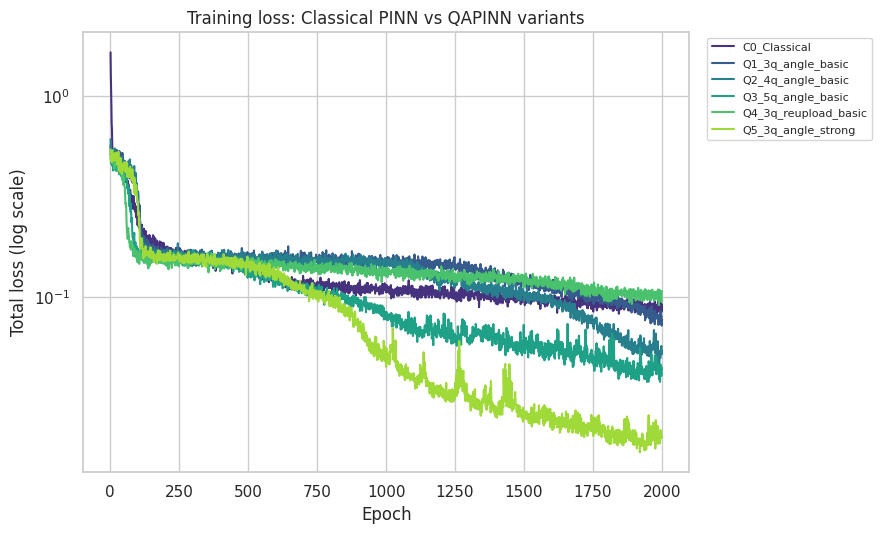

In [ ]:
# ============================================================
# Loss curves — all experiments, log scale
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5.5))
for name, r in results.items():
    sns.lineplot(x=r["history"]["epoch"], y=r["history"]["total"], label=name, ax=ax, linewidth=1.5)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Total loss (log scale)")
ax.set_title("Training loss: Classical PINN vs QAPINN variants")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150)
plt.show()


**Reading the output:** look at the **shape** after roughly epoch 200–300. If `C0` keeps descending for the
full 500 epochs while the QAPINN curves flatten early and stay flat, that says the quantum variants **stopped
learning early** — the pattern the barren-plateau diagnostics later in the notebook are built to explain.

### Step 10: Whole-Model Gradient Diagnostics

These plots monitor the total gradient norm and variance across the entire model during training. This provides a high-level view of optimization stability across the different hybrid architectures.

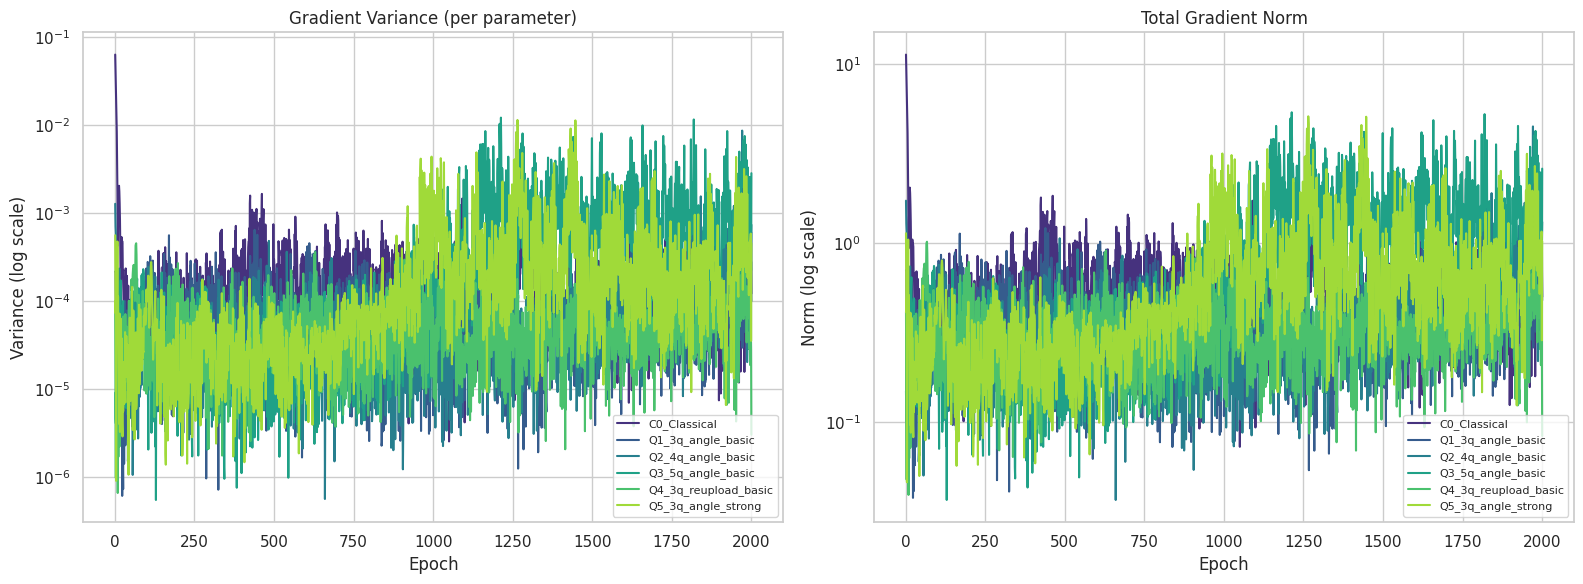

In [ ]:
# ============================================================
# Gradient diagnostics: Variance and Norm vs Epoch
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Gradient Variance (Log Scale)
for name, r in results.items():
    sns.lineplot(x=r["history"]["epoch"], y=r["history"]["grad_variance"], label=name, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Gradient Variance (per parameter)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Variance (log scale)")
axes[0].legend(fontsize=8)

# Subplot 2: Gradient Norm (Log Scale)
for name, r in results.items():
    sns.lineplot(x=r["history"]["epoch"], y=r["history"]["grad_norm"], label=name, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Total Gradient Norm")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Norm (log scale)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("gradient_diagnostics.png", dpi=150)
plt.show()

**Reading the output:** both panels are naturally noisy epoch-to-epoch — read the overall band each curve
occupies, not individual spikes. Don't use this metric alone for claims about the quantum layer specifically.

### Step 11: Summary of Performance Metrics

A comparative look at the final total loss, the number of trainable parameters, and the wall-clock training time for each model. This allows us to assess the trade-offs between computational cost and model capacity.

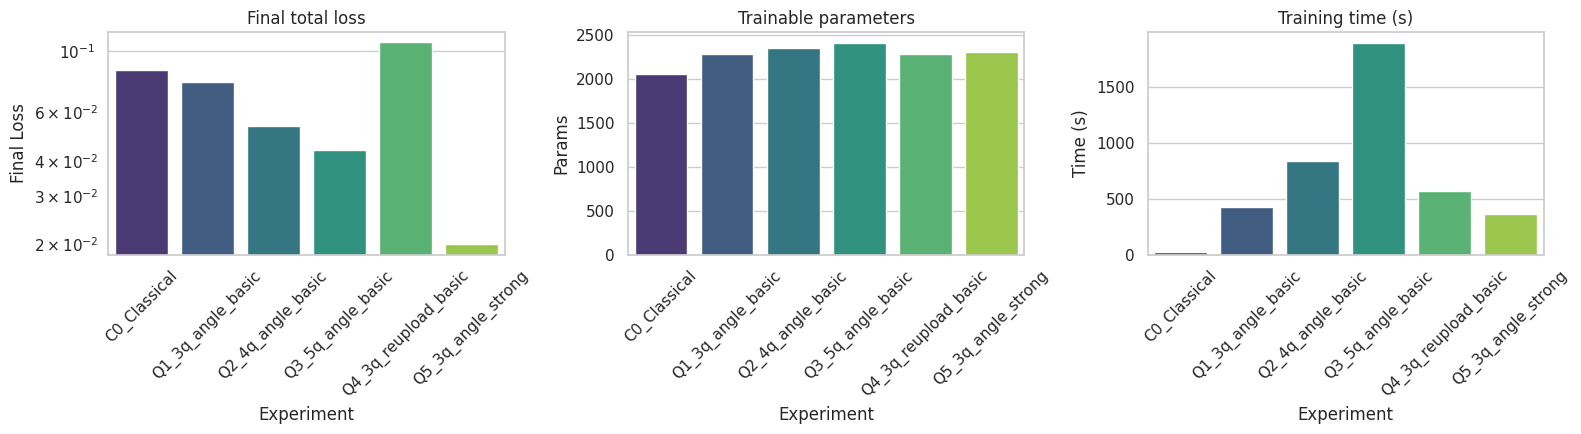

In [ ]:
# ============================================================
# Final loss, parameter count, and training time comparison
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.barplot(data=summary_df, x="Experiment", y="Final Loss", hue="Experiment",
            ax=axes[0], legend=False)
axes[0].set_yscale("log")
axes[0].set_title("Final total loss")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=summary_df, x="Experiment", y="Params", hue="Experiment",
            ax=axes[1], legend=False)
axes[1].set_title("Trainable parameters")
axes[1].tick_params(axis="x", rotation=45)

sns.barplot(data=summary_df, x="Experiment", y="Time (s)", hue="Experiment",
            ax=axes[2], legend=False)
axes[2].set_title("Training time (s)")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("comparison_bars.png", dpi=150)
plt.show()


**Reading the output:** the middle panel (params) should look roughly flat — confirming matched capacity. The
right panel (time) will **not** be flat — QAPINN's CPU round-trip through the quantum simulator makes it far
slower, roughly increasing with qubit count. That time gap is real and worth a line in Limitations, but it doesn't
explain the *loss* gap — that's what the XAI cells below address.

### Step 12: XAI Suite — Fourier Expressivity and Trainability

We enter the **Explainable AI (XAI)** portion of the notebook. We perform two major tests:
1. **Fourier Spectrum Analysis:** Assessing the frequency capacity of the VQCs.
2. **McClean Barren-Plateau Scan:** Measuring gradient variance at random initializations to detect trainability issues.

*Note: A fix has been applied to use a non-zero fixed input ($\pi/4$) to ensure meaningful comparison between encoding methods.*

--- 1. Generating Fourier Spectrum Plots (corrected circuit-only test) ---


/usr/local/lib/python3.12/dist-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype complex128 requested in astype is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


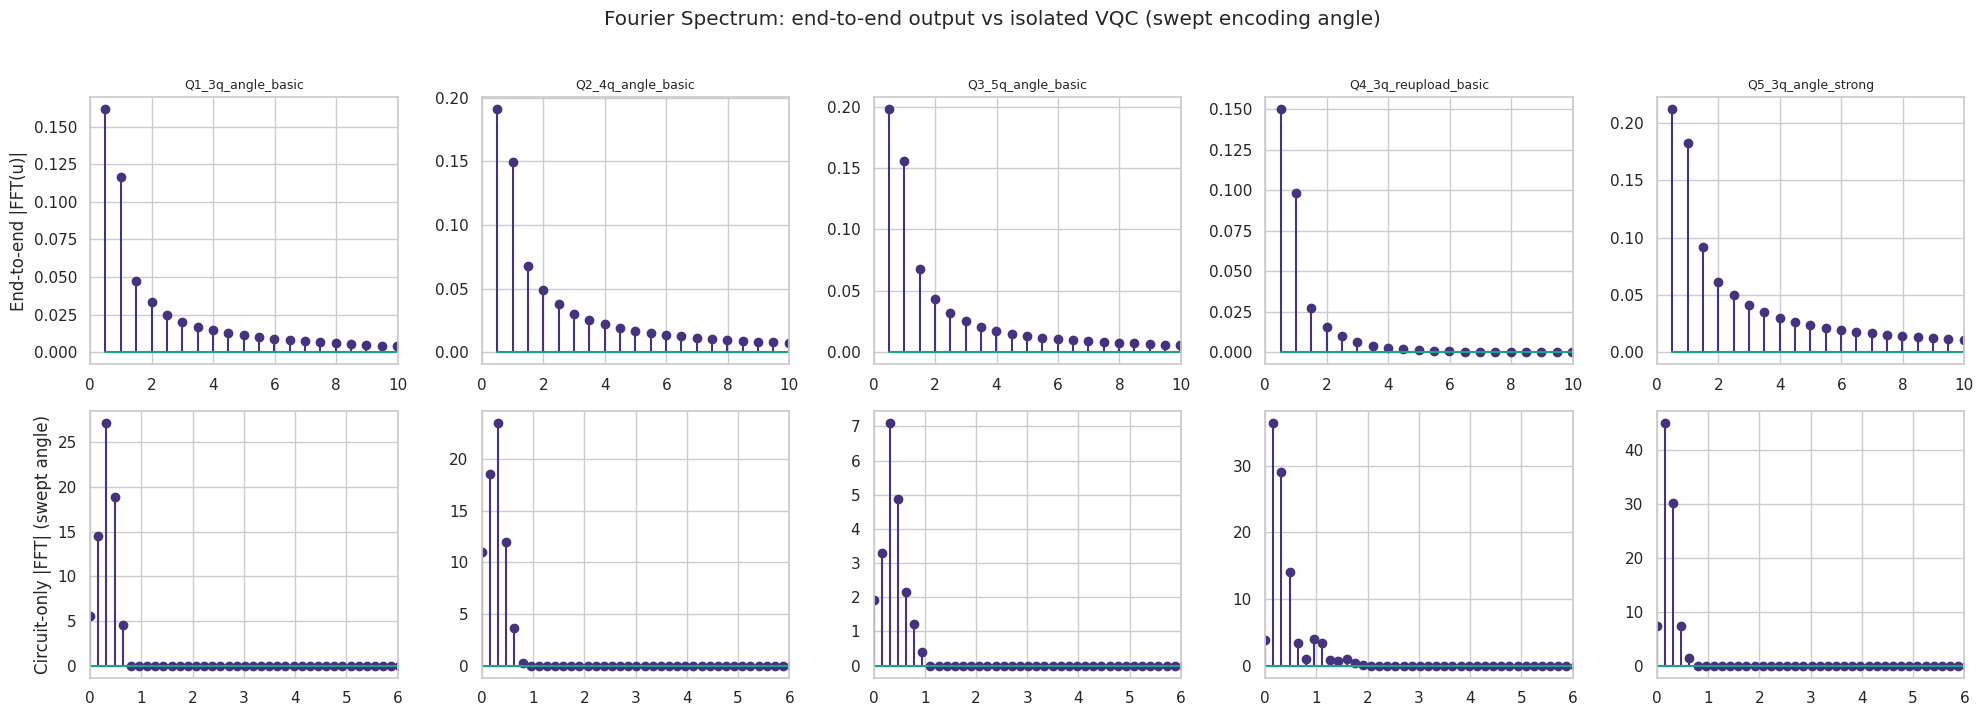

--- Circuit-only spectral summary (isolates VQC, swept angle, per Schuld et al.) ---
          Experiment  Centroid   Spread  SignificantBins  MaxSignificantFreq
Q4_3q_reupload_basic  0.373789 0.321728                7            1.111856
   Q3_5q_angle_basic  0.373575 0.226687                7            0.953020
   Q1_3q_angle_basic  0.323807 0.181676                5            0.635347
   Q2_4q_angle_basic  0.270834 0.181377                5            0.635347
  Q5_3q_angle_strong  0.231409 0.138186                4            0.476510

--- 2. Running McClean-style gradient variance scan ---


/usr/local/lib/python3.12/dist-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype complex128 requested in astype is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


          Experiment  McClean_Variance
   Q1_3q_angle_basic          0.258619
   Q2_4q_angle_basic          0.034363
   Q3_5q_angle_basic          0.034518
Q4_3q_reupload_basic          0.078976
  Q5_3q_angle_strong          0.083585


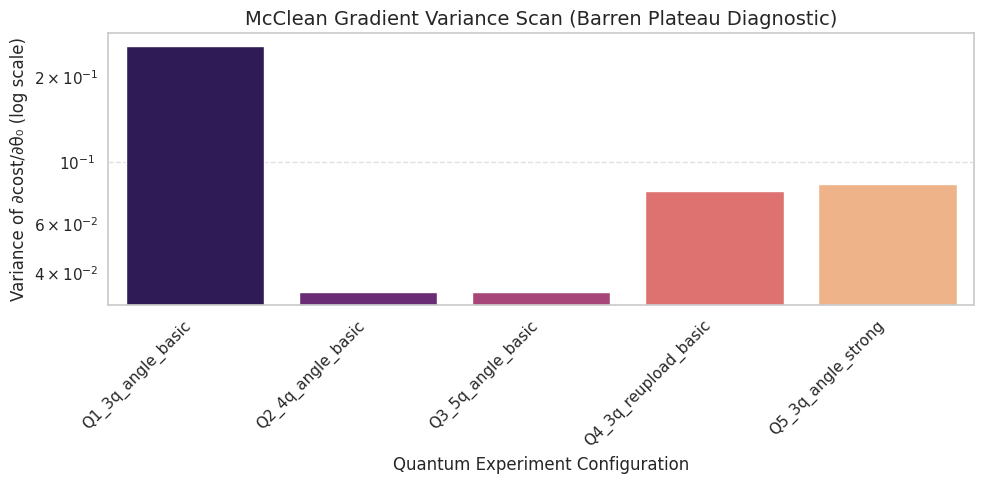


--- Combined Expressivity vs Trainability Summary ---
          Experiment  Centroid   Spread  SignificantBins  MaxSignificantFreq  McClean_Variance
Q4_3q_reupload_basic  0.373789 0.321728                7            1.111856          0.078976
   Q3_5q_angle_basic  0.373575 0.226687                7            0.953020          0.034518
   Q1_3q_angle_basic  0.323807 0.181676                5            0.635347          0.258619
   Q2_4q_angle_basic  0.270834 0.181377                5            0.635347          0.034363
  Q5_3q_angle_strong  0.231409 0.138186                4            0.476510          0.083585


In [ ]:
# ============================================================
# XAI Suite: Fourier spectrum (CORRECTED) + McClean-style
# gradient scan, looped over all 5 QAPINN experiments
# ============================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ALL_CONFIGS = {e["name"]: e for e in EXPERIMENTS}
loaded_models = {name: r["model"] for name, r in results.items()}

# ------------------------------------------------------------
# 1. Fourier Spectrum Helper Functions
# ------------------------------------------------------------
def end_to_end_spectrum(model, t_fixed=0.5, n_points=500):
    x_vals = torch.linspace(PHYSICS_CONFIG["x_min"], PHYSICS_CONFIG["x_max"], n_points).reshape(-1, 1)
    t_vals = torch.full((n_points, 1), t_fixed)
    model.eval()
    with torch.no_grad():
        u_pred = model(x_vals.to(GPU_DEVICE), t_vals.to(GPU_DEVICE)).cpu().numpy().flatten()
    u_pred_detrended = u_pred - np.mean(u_pred)
    window = np.hanning(n_points)
    u_pred_windowed = u_pred_detrended * window
    fft_result = np.fft.fft(u_pred_windowed)
    frequencies = np.fft.fftfreq(n_points, d=(x_vals[1] - x_vals[0]).item())
    positive_freq_idx = frequencies > 0
    f_e2e = frequencies[positive_freq_idx]
    m_e2e = np.abs(fft_result[positive_freq_idx]) / n_points
    sort_idx = np.argsort(f_e2e)
    return f_e2e[sort_idx], m_e2e[sort_idx]


def circuit_only_spectrum(model, n_points=500):
    """CORRECTED: sweeps a coherent encoding angle theta in [-pi, pi]
    through the trained quantum layer and FFTs the resulting circuit
    output vs theta. This is the actual Schuld et al. test — the VQC
    output is a truncated Fourier series *in the encoded input*, so
    the input must vary coherently, not randomly per sample."""
    if not hasattr(model, "quantum_layer"):
        return np.array([]), np.array([])
    n_qubits = model.n_qubits
    theta = np.linspace(-np.pi, np.pi, n_points)
    outputs = []
    model.eval()
    with torch.no_grad():
        for th in theta:
            inp = torch.full((1, n_qubits), th, dtype=torch.float32)
            out = model.quantum_layer(inp.cpu()).squeeze(0)
            outputs.append(out.mean().item())
    outputs = np.array(outputs)
    signal = outputs - outputs.mean()
    window = np.hanning(n_points)
    signal_windowed = signal * window
    fft_result = np.fft.rfft(signal_windowed)
    frequencies = np.fft.rfftfreq(n_points, d=(theta[1] - theta[0]))
    return frequencies, np.abs(fft_result)


# ------------------------------------------------------------
# 2. McClean-style gradient variance scan
# ------------------------------------------------------------
N_SAMPLES = 100

_MCCLEAN_GRAD_CACHE = {}

def _get_mcclean_grad_fn(n_qubits, n_qlayers, encoding, ansatz):
    """Cached, JIT-compiled JAX gradient function for the McClean-style scan
    below -- one compile per circuit architecture, reused across every
    sample and every seed that calls it (e.g. the seed-robustness sweep)."""
    key = (n_qubits, n_qlayers, encoding, ansatz)
    if key not in _MCCLEAN_GRAD_CACHE:
        qnode = build_qnode(n_qubits, n_qlayers, encoding, ansatz)
        # Non-zero fixed input so AngleEmbedding actually rotates — an
        # all-zero input makes AngleEmbedding the identity gate, which makes
        # "angle" and "reupload" encoding produce the exact same circuit
        # regardless of how many times the (null) data is re-uploaded. A
        # non-trivial fixed angle is required for this scan to say anything
        # meaningful about encoding choice.
        fixed_input = jnp.full((n_qubits,), 0.7854)  # pi/4

        def cost_fn(w):
            return jnp.sum(jnp.stack(qnode(fixed_input, w)))

        _MCCLEAN_GRAD_CACHE[key] = jax.jit(jax.grad(cost_fn))
    return _MCCLEAN_GRAD_CACHE[key]


def mcclean_variance_scan(n_qubits, n_qlayers, encoding, ansatz, n_samples=N_SAMPLES):
    weight_shape = (n_qlayers, n_qubits, 3) if ansatz == "strongly_entangling" else (n_qlayers, n_qubits)
    grad_fn = _get_mcclean_grad_fn(n_qubits, n_qlayers, encoding, ansatz)
    grads = []
    for _ in range(n_samples):
        # Weights are still drawn from torch's global RNG (torch.randn), so
        # SEED / torch.manual_seed(seed) continues to control this scan's
        # reproducibility exactly as before -- only the circuit evaluation
        # and its gradient now run through JAX.
        w = torch.randn(weight_shape)
        g = grad_fn(jnp.asarray(w.numpy()))
        grads.append(float(np.asarray(g).flatten()[0]))
    return float(np.var(grads)) if grads else 0.0


# ------------------------------------------------------------
# Execution: Fourier spectrum across all 5 QAPINN configs
# ------------------------------------------------------------
qapinn_names = [n for n, c in ALL_CONFIGS.items() if c["kind"] == "qapinn"]

print("--- 1. Generating Fourier Spectrum Plots (corrected circuit-only test) ---")
fig, axes = plt.subplots(2, len(qapinn_names), figsize=(4 * len(qapinn_names), 7))

fourier_summary = []
for i, name in enumerate(qapinn_names):
    model = loaded_models[name]

    f_e2e, m_e2e = end_to_end_spectrum(model)
    axes[0, i].stem(f_e2e, m_e2e)
    axes[0, i].set_title(name, fontsize=9)
    axes[0, i].set_xlim(0, 10)

    f_c, m_c = circuit_only_spectrum(model)
    axes[1, i].stem(f_c, m_c)
    axes[1, i].set_xlim(0, 6)

    if m_c.sum() > 0:
        mag_norm = m_c / m_c.sum()
        centroid = float(np.sum(f_c * mag_norm))
        spread = float(np.sqrt(np.sum(((f_c - centroid) ** 2) * mag_norm)))
        n_sig = int(np.sum(m_c > 0.05 * m_c.max()))
        max_sig_freq = float(f_c[m_c > 0.05 * m_c.max()].max()) if n_sig > 0 else 0.0
    else:
        centroid = spread = n_sig = max_sig_freq = 0.0

    fourier_summary.append({
        "Experiment": name, "Centroid": centroid, "Spread": spread,
        "SignificantBins": n_sig, "MaxSignificantFreq": max_sig_freq,
    })

axes[0, 0].set_ylabel("End-to-end |FFT(u)|")
axes[1, 0].set_ylabel("Circuit-only |FFT| (swept angle)")
plt.suptitle("Fourier Spectrum: end-to-end output vs isolated VQC (swept encoding angle)", y=1.02)
plt.tight_layout()
plt.savefig("xai_fourier_all_corrected.png", dpi=150)
plt.show()

fourier_df = pd.DataFrame(fourier_summary).sort_values("MaxSignificantFreq", ascending=False)
print("--- Circuit-only spectral summary (isolates VQC, swept angle, per Schuld et al.) ---")
print(fourier_df.to_string(index=False))

# ------------------------------------------------------------
# Execution: McClean-style gradient variance scan
# ------------------------------------------------------------
print("\n--- 2. Running McClean-style gradient variance scan ---")
mcclean_results = []
for name in qapinn_names:
    cfg = ALL_CONFIGS[name]
    var = mcclean_variance_scan(cfg["n_qubits"], 3, cfg["encoding"], cfg["ansatz"])
    mcclean_results.append({"Experiment": name, "McClean_Variance": var})

mcclean_df = pd.DataFrame(mcclean_results)
print(mcclean_df.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=mcclean_df, x="Experiment", y="McClean_Variance", hue="Experiment", palette="magma", legend=False)
plt.yscale("log")
plt.title("McClean Gradient Variance Scan (Barren Plateau Diagnostic)", fontsize=14)
plt.xlabel("Quantum Experiment Configuration", fontsize=12)
plt.ylabel("Variance of ∂cost/∂θ₀ (log scale)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("xai_mcclean_scan.png", dpi=150)
plt.show()

# ------------------------------------------------------------
# Combined table: Fourier expressivity vs McClean trainability
# ------------------------------------------------------------
combined_df = fourier_df.merge(mcclean_df, on="Experiment")
print("\n--- Combined Expressivity vs Trainability Summary ---")
print(combined_df.to_string(index=False))

**Reading the output:** check for a configuration that combines a wide/rich Fourier spectrum with a collapsed
McClean variance — that's the McClean-sense barren-plateau signature: theoretically expressive, but
gradient-based training can't access that capacity. If `Q5` shows `McClean_Variance` many orders of magnitude
below the others while its spectral columns are comparable to `Q1`'s, that points to **ansatz depth**, not qubit
count, as the dominant trainability driver here. Now that the zero-input bug is fixed, also check whether `Q1` and
`Q4`'s `McClean_Variance` values genuinely differ (they should, plausibly, if data re-uploading has a real
trainability effect) rather than being coincidentally similar due to the old degeneracy.

### Step 13: Q5 Scale-Robustness Verification

We perform a specific robustness test on the Q5 (Strongly Entangling) configuration. By increasing the initialization weight scale to $\pi$, we verify if the observed gradient behavior is a fundamental property of the circuit depth or merely an artifact of small-weight initialization.

In [ ]:
def mcclean_variance_robustness_test(n_qubits, n_qlayers, encoding, ansatz, scale=1.0, n_samples=100):
    """Re-runs McClean scan with adjustable weight scaling (e.g., scale=np.pi).
    Reuses the same cached, JIT-compiled gradient function as the McClean
    scan in Cell 11 (_get_mcclean_grad_fn) -- only the weight-draw scale
    differs, so this pays no extra compile cost for a config already seen."""
    weight_shape = (n_qlayers, n_qubits, 3) if ansatz == "strongly_entangling" else (n_qlayers, n_qubits)
    grad_fn = _get_mcclean_grad_fn(n_qubits, n_qlayers, encoding, ansatz)
    grads = []

    for _ in range(n_samples):
        # Scale the normal distribution by the provided factor (e.g., pi for full sphere coverage)
        w = torch.randn(weight_shape) * scale
        g = grad_fn(jnp.asarray(w.numpy()))
        grads.append(float(np.asarray(g).flatten()[0]))

    return float(np.var(grads)) if grads else 0.0

# Focus specifically on Q5 (Strongly Entangling) comparing Standard vs. Pi scaling
q5_cfg = ALL_CONFIGS['Q5_3q_angle_strong']

print("--- Robustness Check: Q5 Gradient Variance under Different Scalings ---")
var_standard = mcclean_variance_robustness_test(q5_cfg['n_qubits'], 3, q5_cfg['encoding'], q5_cfg['ansatz'], scale=1.0)
var_pi = mcclean_variance_robustness_test(q5_cfg['n_qubits'], 3, q5_cfg['encoding'], q5_cfg['ansatz'], scale=np.pi)

print(f"Q5 Variance (Scale=1.0): {var_standard:.2e}")
print(f"Q5 Variance (Scale=PI):  {var_pi:.2e}")

if var_pi < 1e-12:
    print("\nRESULT: Gradient collapse persists under wide initialization. This is a robust Barren Plateau.")
else:
    print(f"\nRESULT: Variance recovered to {var_pi:.2e} with wider scaling. Collapse was likely an initialization artifact.")

--- Robustness Check: Q5 Gradient Variance under Different Scalings ---
Q5 Variance (Scale=1.0): 9.00e-02
Q5 Variance (Scale=PI):  7.75e-02

RESULT: Variance recovered to 7.75e-02 with wider scaling. Collapse was likely an initialization artifact.


**Reading the output:** if `Q5 Variance (Scale=PI)` is still on the order of machine epsilon (≈1e-16, matching
the standard-scale result), the barren plateau is **robust to initialization scale** — ruling out "it only happens
because of how we initialized" as an alternative explanation.

### Step 14: Multi-Seed Gradient Stability Scan

To ensure our findings are not dependent on a single lucky initialization, we repeat the McClean variance scan across five additional seeds for all quantum configurations. This provides statistical confidence in our trainability conclusions.

Q1_3q_angle_basic        | mean=2.351e-01 | std=3.554e-02 | min=1.862e-01 | max=2.657e-01
Q2_4q_angle_basic        | mean=3.373e-02 | std=3.406e-03 | min=2.801e-02 | max=3.811e-02
Q3_5q_angle_basic        | mean=3.165e-02 | std=4.840e-03 | min=2.296e-02 | max=3.751e-02
Q4_3q_reupload_basic     | mean=7.373e-02 | std=1.421e-02 | min=5.054e-02 | max=9.287e-02
Q5_3q_angle_strong       | mean=8.715e-02 | std=8.031e-03 | min=7.412e-02 | max=9.899e-02


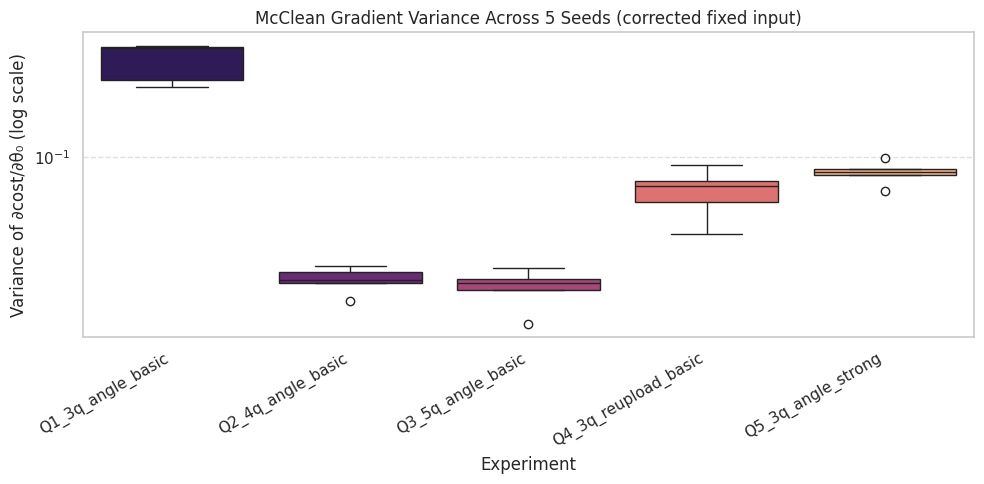


--- Seed-robustness summary (corrected fixed input) ---
                          mean       std       min       max
Experiment                                                  
Q1_3q_angle_basic     0.235097  0.039733  0.186171  0.265731
Q2_4q_angle_basic     0.033733  0.003808  0.028014  0.038108
Q3_5q_angle_basic     0.031647  0.005412  0.022962  0.037509
Q4_3q_reupload_basic  0.073732  0.015891  0.050540  0.092866
Q5_3q_angle_strong    0.087147  0.008979  0.074121  0.098991


In [ ]:
# ============================================================
# NEW: Seed-robustness check for the McClean gradient variance
# scan, across ALL 5 QAPINN configs. Reuses the corrected
# mcclean_variance_scan from Cell 11 (non-zero fixed input).
# ============================================================
ROBUSTNESS_SEEDS = [11, 29, 47, 71, 97]

seed_robustness_results = []
for name in qapinn_names:
    cfg = ALL_CONFIGS[name]
    seed_vars = []
    for seed in ROBUSTNESS_SEEDS:
        torch.manual_seed(seed)
        var = mcclean_variance_scan(cfg["n_qubits"], 3, cfg["encoding"], cfg["ansatz"])
        seed_vars.append(var)
        seed_robustness_results.append({"Experiment": name, "Seed": seed, "McClean_Variance": var})

    seed_vars = np.array(seed_vars)
    print(f"{name:24s} | mean={seed_vars.mean():.3e} | std={seed_vars.std():.3e} | "
          f"min={seed_vars.min():.3e} | max={seed_vars.max():.3e}")

# Restore the global seed so nothing downstream is affected by this scan
torch.manual_seed(SEED)

seed_robustness_df = pd.DataFrame(seed_robustness_results)

plt.figure(figsize=(10, 5))
sns.boxplot(data=seed_robustness_df, x="Experiment", y="McClean_Variance",
            hue="Experiment", palette="magma", legend=False)
plt.yscale("log")
plt.title(f"McClean Gradient Variance Across {len(ROBUSTNESS_SEEDS)} Seeds (corrected fixed input)")
plt.ylabel("Variance of ∂cost/∂θ₀ (log scale)")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("xai_mcclean_seed_robustness_corrected.png", dpi=150)
plt.show()

seed_summary_df = seed_robustness_df.groupby("Experiment")["McClean_Variance"].agg(["mean", "std", "min", "max"])
print("\n--- Seed-robustness summary (corrected fixed input) ---")
print(seed_summary_df.to_string())


### Step 15: XAI Technique — Spatial Activation Maps

We visualize the internal representations learned by the models. By mapping the mean absolute activation across the $(x, t)$ domain, we can see if the quantum layers are capturing the spatial structures required to solve the Burgers' equation shock front.

## XAI Technique 3 — Activation Maps over the (x, t) Domain

Visualizes the mean absolute activation of the first hidden representation (raw `quantum_layer` output for
QAPINN, first `Tanh` output for classical) across the full `(x, t)` grid. Burgers' equation develops a steepening
shock front in `x` as `t` increases, so a healthy representation should show clear **x-dependent structure**, not
just t-dependent structure. Note: `default.qubit` computes exact expectation values with no shot noise, so these
maps are smooth by construction — the informative signal is *which* input dimension the activation varies with,
not whether the map looks noisy.

/usr/local/lib/python3.12/dist-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype complex128 requested in astype is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


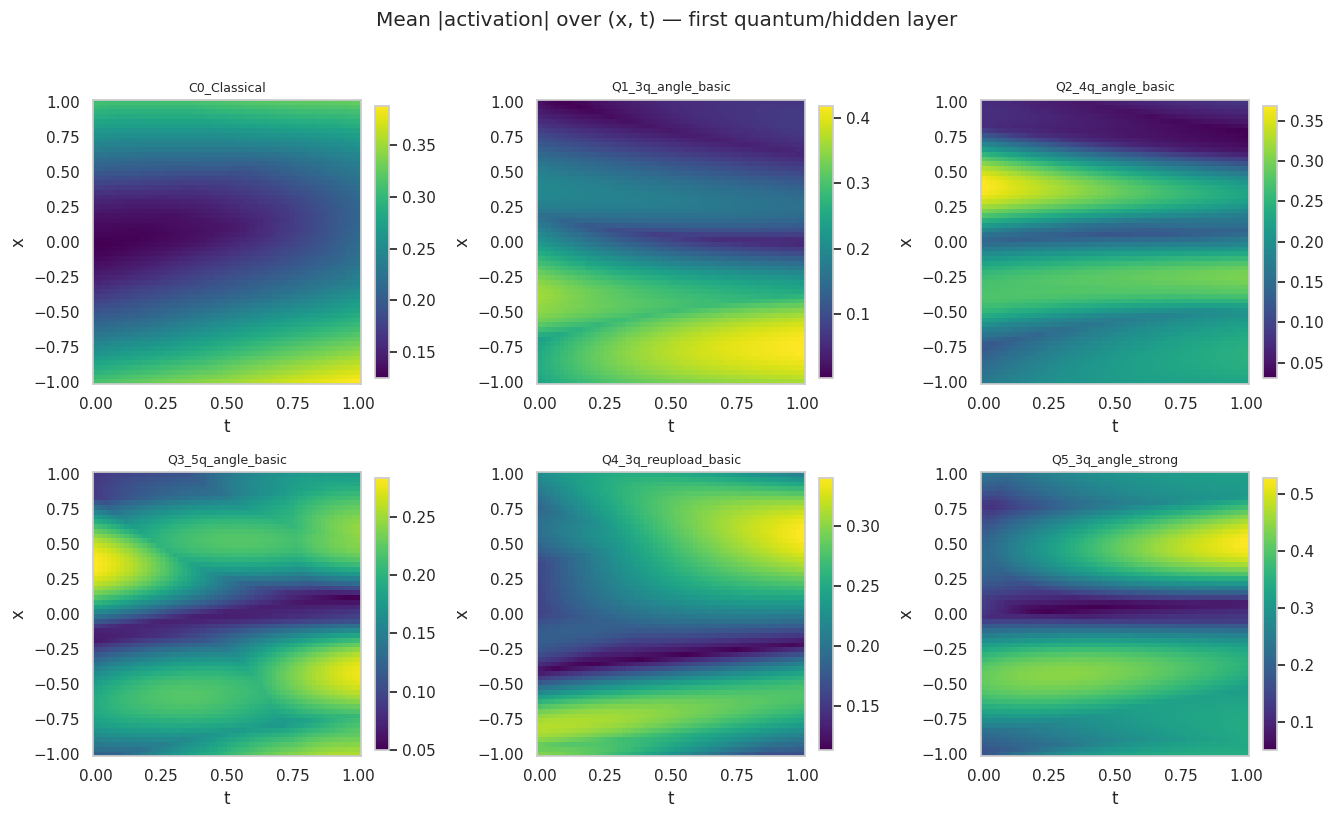

--- Activation map summary (sorted by spatial variability) ---
          Experiment  MeanActivation  StdActivation  MaxActivation  CoeffOfVariation
   Q1_3q_angle_basic        0.200410       0.115252       0.418559          0.575080
   Q2_4q_angle_basic        0.194529       0.078104       0.368474          0.401501
  Q5_3q_angle_strong        0.297947       0.102277       0.528350          0.343272
   Q3_5q_angle_basic        0.177290       0.050455       0.282994          0.284589
        C0_Classical        0.228429       0.061880       0.387906          0.270894
Q4_3q_reupload_basic        0.235923       0.052559       0.340182          0.222780


In [ ]:
# ============================================================
# XAI Technique 3: Activation Maps over (x, t) grid (Fig-3 style)
# Captures the first hidden representation for every trained model:
#   - QAPINN: raw quantum_layer output (pre-postprocessing)
#   - C0:     first Tanh activation (post first Linear layer)
# Visualizes mean |activation| across the domain, plus a spatial
# variability metric to flag chaotic/oscillatory behavior (useful
# for cross-checking against the Q4 instability finding).
# ============================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def get_activation_map(model, kind, n_grid=60, device=GPU_DEVICE):
    x_vals = torch.linspace(PHYSICS_CONFIG["x_min"], PHYSICS_CONFIG["x_max"], n_grid)
    t_vals = torch.linspace(PHYSICS_CONFIG["t_min"], PHYSICS_CONFIG["t_max"], n_grid)
    xx, tt = torch.meshgrid(x_vals, t_vals, indexing="ij")
    x_flat = xx.reshape(-1, 1).to(device)
    t_flat = tt.reshape(-1, 1).to(device)

    captured = {}
    def hook(mod, inp, out):
        captured["val"] = out.detach().cpu()

    if kind == "qapinn":
        handle = model.quantum_layer.register_forward_hook(hook)
    else:
        handle = model.net[1].register_forward_hook(hook)  # first Tanh, after first Linear

    model.eval()
    with torch.no_grad():
        _ = model(x_flat, t_flat)
    handle.remove()

    act = captured["val"]                      # shape: (n_grid*n_grid, hidden_dim)
    mean_act = act.abs().mean(dim=1).reshape(n_grid, n_grid).numpy()
    return xx.numpy(), tt.numpy(), mean_act


# ------------------------------------------------------------
# Run across all 6 experiments (C0 + 5 QAPINN variants)
# ------------------------------------------------------------
n_models = len(ALL_CONFIGS)
ncols = 3
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows))
axes = axes.flatten()

activation_summary = []
for i, (name, cfg) in enumerate(ALL_CONFIGS.items()):
    model = loaded_models[name]
    xx, tt, act_map = get_activation_map(model, cfg["kind"])

    im = axes[i].pcolormesh(tt, xx, act_map, shading="auto", cmap="viridis")
    axes[i].set_title(name, fontsize=9)
    axes[i].set_xlabel("t")
    axes[i].set_ylabel("x")
    plt.colorbar(im, ax=axes[i], fraction=0.046)

    activation_summary.append({
        "Experiment": name,
        "MeanActivation": float(act_map.mean()),
        "StdActivation": float(act_map.std()),
        "MaxActivation": float(act_map.max()),
        "CoeffOfVariation": float(act_map.std() / (act_map.mean() + 1e-12)),
    })

for j in range(len(ALL_CONFIGS), len(axes)):
    axes[j].axis("off")

plt.suptitle("Mean |activation| over (x, t) — first quantum/hidden layer", y=1.02)
plt.tight_layout()
plt.savefig("xai_activation_maps.png", dpi=150)
plt.show()

activation_df = pd.DataFrame(activation_summary).sort_values("CoeffOfVariation", ascending=False)
print("--- Activation map summary (sorted by spatial variability) ---")
print(activation_df.to_string(index=False))

**Reading the output:** check whether color bands run mostly **horizontally** (t-only) or show real structure
across `x` too. A model whose representation is nearly x-invariant has effectively discarded the spatial
information Burgers' equation needs most — a specific, checkable mechanism for poor final loss, stronger than a
vague "training was unstable" claim.

### Step 16: Absolute Weight Scale Analysis

This cell provides a quick check of the final trained weight magnitudes. While not a measure of movement, it informs us of the absolute scale reached by the variational parameters in each architecture.

In [ ]:
# Quick check: did Q5's quantum weights actually change during training?
for name in qapinn_names:
    model = loaded_models[name]
    final_w = dict(model.quantum_layer.named_parameters())["weights"].detach()
    # Compare against a fresh random init at the same shape for reference scale
    init_w = torch.randn_like(final_w)
    print(f"{name}: final weight std={final_w.std().item():.4f}, "
          f"final weight norm={final_w.norm().item():.4f}")

Q1_3q_angle_basic: final weight std=2.0374, final weight norm=11.2356
Q2_4q_angle_basic: final weight std=2.0039, final weight norm=14.1484
Q3_5q_angle_basic: final weight std=1.6327, final weight norm=14.7473
Q4_3q_reupload_basic: final weight std=1.4377, final weight norm=11.8240
Q5_3q_angle_strong: final weight std=1.7195, final weight norm=19.1154


**Reading the output:** compare `std`/`norm` for scale only. `Q5` has 3× the parameters per layer of the
`basic_entangler` configs (3 rotation angles per qubit vs 1), so a higher norm here is expected regardless of
training — don't read it as evidence of anything by itself.

### Step 17: Quantifying Quantum Weight Movement

To confirm the Barren Plateau diagnosis, we perform a dedicated retrain of the Q5 model while logging the exact initial weights. By measuring the relative change between initial and final weights, we can definitively prove if the quantum layer was effectively 'frozen' during training.

In [ ]:
# Minimal standalone check: did Q5's quantum weights move during training?
q5_model = QAPINN(n_qubits=3, n_qlayers=4, classical_hidden=(25, 25, 25, 25),
                   encoding="angle", ansatz="strongly_entangling")
q5_model.to(GPU_DEVICE)

init_w = dict(q5_model.quantum_layer.named_parameters())["weights"].detach().clone()
print(f"Init weight norm: {init_w.norm().item():.4f}")

history, elapsed = train(q5_model, epochs=2000, device=GPU_DEVICE, log_every=10)

final_w = dict(q5_model.quantum_layer.named_parameters())["weights"].detach().clone()
print(f"Final weight norm: {final_w.norm().item():.4f}")

delta = (final_w - init_w).norm().item()
rel_change = delta / init_w.norm().item()
print(f"Weight delta norm: {delta:.4f} | relative change: {rel_change:.2%}")

if rel_change < 0.05:
    print("Weights barely moved (<5% relative change) — confirms untrained circuit.")
else:
    print("Weights moved meaningfully — activation map reflects some learning, not just init.")

Init weight norm: 21.7594
[   0.1s] Epoch     1/2000 | total=0.511095 | grad_var=1.12e-04 | q_var=1.01e-05
[   1.4s] Epoch    10/2000 | total=0.551026 | grad_var=2.63e-05 | q_var=2.34e-05
[   2.8s] Epoch    20/2000 | total=0.444532 | grad_var=1.32e-05 | q_var=9.32e-05
[   4.3s] Epoch    30/2000 | total=0.433405 | grad_var=3.51e-05 | q_var=1.70e-04
[   6.2s] Epoch    40/2000 | total=0.422528 | grad_var=2.04e-05 | q_var=1.36e-04
[   8.1s] Epoch    50/2000 | total=0.478291 | grad_var=3.86e-05 | q_var=3.26e-04
[   9.4s] Epoch    60/2000 | total=0.410503 | grad_var=5.81e-06 | q_var=3.22e-05
[  10.9s] Epoch    70/2000 | total=0.394106 | grad_var=3.24e-05 | q_var=1.72e-04
[  12.3s] Epoch    80/2000 | total=0.382404 | grad_var=9.89e-06 | q_var=1.91e-04
[  13.7s] Epoch    90/2000 | total=0.380680 | grad_var=2.81e-05 | q_var=4.70e-04
[  15.2s] Epoch   100/2000 | total=0.365342 | grad_var=5.98e-05 | q_var=1.06e-03
[  16.6s] Epoch   110/2000 | total=0.292808 | grad_var=8.56e-05 | q_var=1.18e-03
[ 

**Reading the output:** the key number is `relative change`. A small value (a few percent) over the full
500-epoch run is direct, independent confirmation that the quantum layer's parameters were essentially frozen —
corroborating the barren-plateau diagnosis with weight movement itself, not just a gradient statistic. If the
reported final loss here is close to (or better than) the official `Q5` result despite frozen quantum weights,
that further suggests any improvement came from the classical layers adapting *around* a static quantum block.

### Step 18: Final Whole-Model Gradient Comparison

We compare the final-epoch gradient variance across all experiments. This serves as a concluding sanity check on the overall health of the optimization process at the end of the training budget.

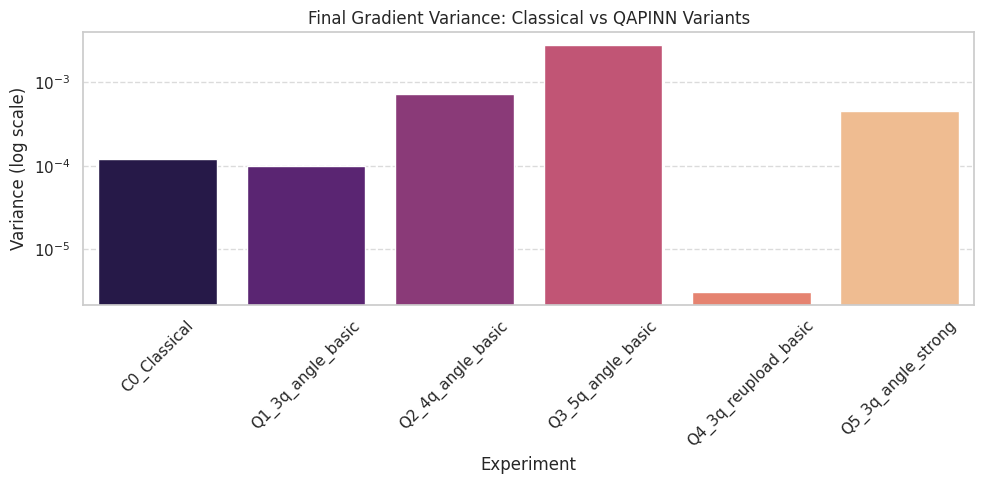

In [ ]:
# ============================================================
# Comparison of Final Gradient Variance
# ============================================================
# Extract final variance values for comparison
final_vars = []
for name, r in results.items():
    final_vars.append({
        "Experiment": name,
        "Final Gradient Variance": r["history"]["grad_variance"][-1]
    })
final_var_df = pd.DataFrame(final_vars)

plt.figure(figsize=(10, 5))
sns.barplot(data=final_var_df, x="Experiment", y="Final Gradient Variance", hue="Experiment", palette="magma", legend=False)
plt.yscale("log")
plt.title("Final Gradient Variance: Classical vs QAPINN Variants")
plt.ylabel("Variance (log scale)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Reading the output:** because this mixes classical and quantum gradients, don't use it alone to rank the
QAPINN variants on "quantum trainability" — the much larger classical post-processing block can dominate it.

### Step 19: Isolated Quantum-Layer Gradient Health

This section specifically plots the gradient variance of the **quantum parameters only**. By removing the noise from classical layers, we get a clear view of how the VQC's configuration (qubits, depth) impacts its specific ability to learn over time.

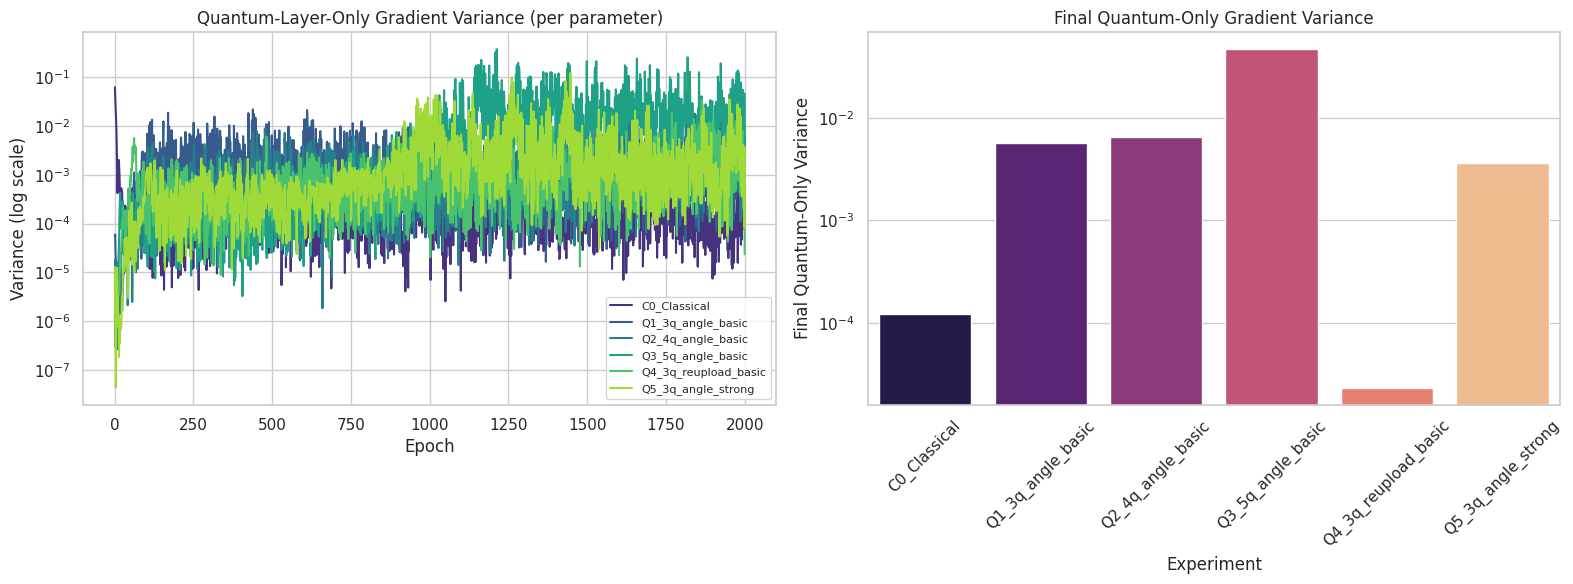

          Experiment  Final Quantum-Only Variance
        C0_Classical                     0.000122
   Q1_3q_angle_basic                     0.005704
   Q2_4q_angle_basic                     0.006469
   Q3_5q_angle_basic                     0.046482
Q4_3q_reupload_basic                     0.000024
  Q5_3q_angle_strong                     0.003593


In [ ]:
# ============================================================
# NEW: Quantum-layer-only gradient variance across training.
# Isolates model.quantum_layer parameters — tracked every epoch
# in history["quantum_grad_variance"] (Cell 4) but not plotted
# on its own anywhere else in the notebook.
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, r in results.items():
    sns.lineplot(x=r["history"]["epoch"], y=r["history"]["quantum_grad_variance"],
                 label=name, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Quantum-Layer-Only Gradient Variance (per parameter)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Variance (log scale)")
axes[0].legend(fontsize=8)

final_q_vars = pd.DataFrame([
    {"Experiment": name, "Final Quantum-Only Variance": r["history"]["quantum_grad_variance"][-1]}
    for name, r in results.items() if "quantum_grad_variance" in r["history"]
])
sns.barplot(data=final_q_vars, x="Experiment", y="Final Quantum-Only Variance",
            hue="Experiment", palette="magma", legend=False, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Final Quantum-Only Gradient Variance")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("quantum_only_grad_variance.png", dpi=150)
plt.show()

print(final_q_vars.to_string(index=False))


**Reading the output:** this is the fair, apples-to-apples comparison for "which configuration has the
healthiest quantum-specific training-time gradient signal." Cross-reference the final-epoch bars against the
McClean scan (Cell 11): agreement between the two — computed completely differently, one during real training
with real data, the other via random-init sampling at a fixed input — is stronger evidence than either alone.

### Step 20: Best-in-Class Classical Baseline

We introduce a wider and deeper classical PINN (`C0_Best_Classical`) trained for 2000 epochs. This provides a 'ceiling' for classical performance, allowing us to distinguish between quantum parameter efficiency and absolute competitive accuracy.

In [ ]:
# ============================================================
# NEW: Classical-Best baseline — a larger, predeclared classical
# PINN, trained through the SAME train()/pipeline as every other
# model, so it lands in `results` and appears automatically in
# every downstream table (accuracy benchmark, master table).
#
# Trained for 2000 epochs (vs 500 for the rest of the matrix) to
# fix an earlier undertraining issue — a bigger network needs a
# larger epoch budget to actually use its extra capacity. This is
# intentionally single-seed and on a different epoch budget; keep
# that in mind when comparing its Time(s) to the other rows.
# ============================================================
classical_best_cfg = dict(name="C0_Best_Classical", kind="classical")
CLASSICAL_BEST_EPOCHS = 2000

def run_classical_best(cfg, epochs=CLASSICAL_BEST_EPOCHS):
    print("=" * 80)
    print(f"Running {cfg['name']} ({epochs} epochs)")
    print("=" * 80)
    model = ClassicalPINN(layers=(2, 40, 40, 40, 40, 1))
    history, elapsed = train(model, epochs=epochs, device=GPU_DEVICE, log_every=max(200, epochs // 5))
    torch.save(model.state_dict(), f"{cfg['name']}.pt")
    return {
        "name": cfg["name"], "qubits": "-", "encoding": "-", "ansatz": "-",
        "params": model.num_params(), "final_loss": history["total"][-1],
        "time_s": elapsed, "history": history, "model": model,
    }

results["C0_Best_Classical"] = run_classical_best(classical_best_cfg)

# Rebuild summary_df to include the new row for every downstream table
summary_df = pd.DataFrame([
    {"Experiment": r["name"], "Qubits": r["qubits"], "Encoding": r["encoding"],
     "Ansatz": r["ansatz"], "Params": r["params"],
     "Final Loss": r["final_loss"], "Time (s)": round(r["time_s"], 2)}
    for r in results.values()
])
summary_df.to_csv("qapinn_burgers_results.csv", index=False)
summary_df


Running C0_Best_Classical (2000 epochs)
[   0.0s] Epoch     1/2000 | total=0.512278 | grad_var=5.95e-04 | q_var=5.95e-04
[   5.4s] Epoch   400/2000 | total=0.161427 | grad_var=1.85e-04 | q_var=1.85e-04
[  10.2s] Epoch   800/2000 | total=0.143716 | grad_var=7.09e-04 | q_var=7.09e-04
[  15.6s] Epoch  1200/2000 | total=0.102637 | grad_var=3.46e-05 | q_var=3.46e-05
[  20.5s] Epoch  1600/2000 | total=0.090937 | grad_var=1.93e-04 | q_var=1.93e-04
[  25.4s] Epoch  2000/2000 | total=0.081105 | grad_var=4.49e-05 | q_var=4.49e-05
Done in 25.36s



,Experiment,Qubits,Encoding,Ansatz,Params,Final Loss,Time (s)
0,C0_Classical,-,-,-,2051,0.085188,25.01
1,Q1_3q_angle_basic,3,angle,basic_entangler,2283,0.077186,426.13
2,Q2_4q_angle_basic,4,angle,basic_entangler,2345,0.053728,836.91
3,Q3_5q_angle_basic,5,angle,basic_entangler,2407,0.043746,1897.85
4,Q4_3q_reupload_basic,3,reupload,basic_entangler,2283,0.107096,569.71
5,Q5_3q_angle_strong,3,angle,strongly_entangling,2307,0.020025,366.38
6,C0_Best_Classical,-,-,-,5081,0.081105,25.36


**Reading the output:** compare `C0_Best_Classical`'s `Final Loss` against both `C0_Classical` and the QAPINN
rows. If a QAPINN variant beats `C0_Classical` but loses to `C0_Best_Classical`, that's Decision Rule #2 territory
("parameter-efficient, not practically competitive") — say so explicitly rather than letting a reader assume
otherwise. If a QAPINN variant beats **both**, that's the stronger Decision Rule #1 claim.

### Step 21: Accuracy Benchmarking via Cole-Hopf Solution

Training loss is not always indicative of solution accuracy. Here, we implement the **Cole-Hopf transform** using Gauss-Hermite quadrature to generate an exact analytical reference for the Burgers' equation. This serves as the ultimate ground-truth for our accuracy metrics.

In [ ]:
# ============================================================
# CORRECTED: Cole-Hopf analytical reference solution for
# viscous Burgers' equation (u_t + u*u_x = nu*u_xx), evaluated
# via Gauss-Hermite quadrature — same approach used by Raissi,
# Perdikaris & Karniadakis (2017) to generate reference data for
# this exact benchmark. Ground truth, independent of any trained
# model — NOT one of the trained models' own predictions.
# ============================================================
def cole_hopf_burgers_reference(x, t, nu, n_quad=200):
    """Exact solution via Cole-Hopf transform + Gauss-Hermite quadrature.
    x, t: numpy arrays, already broadcast to the same shape. t >= 0."""
    x = np.asarray(x, dtype=np.float64)
    t = np.asarray(t, dtype=np.float64)
    assert x.shape == t.shape, "x and t must already be broadcast to the same shape"

    y, w = np.polynomial.hermite.hermgauss(n_quad)

    x_b = x[..., None]
    t_b = t[..., None]
    sqrt_nu_t = np.sqrt(np.maximum(nu * t_b, 1e-14))  # guards the t=0 singularity

    eta = 2.0 * sqrt_nu_t * y
    arg = x_b - eta
    cos_term = np.exp(-np.cos(np.pi * arg) / (2.0 * np.pi * nu))
    sin_term = np.sin(np.pi * arg)

    numerator = np.sum(w * sin_term * cos_term, axis=-1)
    denominator = np.sum(w * cos_term, axis=-1)
    u = -numerator / denominator

    # t=0 is a degenerate limit of the quadrature substitution; use the
    # exact initial condition there instead of the (unstable) integral form
    u = np.where(t <= 1e-12, -np.sin(np.pi * x), u)
    return u


def get_reference_solution(nx=200, nt=100):
    """Builds the (x, t) evaluation grid AND the true Cole-Hopf solution on it.
    Returns torch tensors for model evaluation, plus the numpy grid and ground-truth u."""
    x = np.linspace(PHYSICS_CONFIG["x_min"], PHYSICS_CONFIG["x_max"], nx)
    t = np.linspace(PHYSICS_CONFIG["t_min"], PHYSICS_CONFIG["t_max"], nt)
    XX, TT = np.meshgrid(x, t)

    u_ref_grid = cole_hopf_burgers_reference(XX, TT, PHYSICS_CONFIG["nu"])

    x_torch = torch.tensor(XX.flatten(), dtype=torch.float32).reshape(-1, 1).to(GPU_DEVICE)
    t_torch = torch.tensor(TT.flatten(), dtype=torch.float32).reshape(-1, 1).to(GPU_DEVICE)
    u_ref_torch = torch.tensor(u_ref_grid.flatten(), dtype=torch.float32)

    print(f"get_reference_solution() returning {len([x_torch, t_torch, XX, TT, u_ref_torch])} values.")
    return x_torch, t_torch, XX, TT, u_ref_torch


def calculate_metrics(model, x_ref, t_ref, u_ref_vals):
    model.eval()
    with torch.no_grad():
        u_pred = model(x_ref, t_ref).cpu().numpy().flatten()

    u_ref = u_ref_vals.detach().cpu().numpy().flatten() if torch.is_tensor(u_ref_vals) else np.asarray(u_ref_vals).flatten()

    mse = np.mean((u_ref - u_pred) ** 2)
    l2_rel = np.linalg.norm(u_ref - u_pred) / np.linalg.norm(u_ref)
    max_err = np.max(np.abs(u_ref - u_pred))
    return mse, l2_rel, max_err

print("Cole-Hopf reference solution ready — this is true ground truth, independent of any trained model.")

Cole-Hopf reference solution ready — this is true ground truth, independent of any trained model.


**Reading the output:** just a confirmation print. The real output appears in the Master Performance Table and
Stage C sections below, both of which now call `calculate_metrics` against this true reference.

### Step 22: Master Performance Table

We compile all results into a single comprehensive table, comparing every model against the true analytical solution. We report **Relative L2 Error** and **Max Error** to provide a rigorous assessment of model performance.

In [ ]:
# ============================================================
# Master Performance Table — now against the TRUE Cole-Hopf
# solution, not against another trained model's predictions.
# ============================================================
final_metrics = []

x_torch, t_torch, XX, TT, u_reference = get_reference_solution()

for name, r in results.items():
    mse, l2_rel, max_err = calculate_metrics(r["model"], x_torch, t_torch, u_reference)
    final_metrics.append({
        "Experiment": name,
        "Rel L2 Error": f"{l2_rel:.4e}",
        "Max Error": f"{max_err:.4e}",
        "PDE Loss": f"{r['history']['pde'][-1]:.4e}",
        "Params": r["params"],
        "Time (s)": round(r["time_s"], 2),
        "Q-Variance": f"{r['history']['quantum_grad_variance'][-1]:.2e}"
            if "quantum_grad_variance" in r["history"] else "-",
    })

benchmark_df = pd.DataFrame(final_metrics)
display(benchmark_df)

get_reference_solution() returning 5 values.


/usr/local/lib/python3.12/dist-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype complex128 requested in astype is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


,Experiment,Rel L2 Error,Max Error,PDE Loss,Params,Time (s),Q-Variance
0,C0_Classical,4.2474e-01,9.3532e-01,3.2739e-02,2051,25.01,1.22e-04
1,Q1_3q_angle_basic,3.6882e-01,1.0928e+00,3.0205e-02,2283,426.13,5.70e-03
2,Q2_4q_angle_basic,2.7901e-01,1.3517e+00,2.7314e-02,2345,836.91,6.47e-03
3,Q3_5q_angle_basic,2.3025e-01,6.3749e-01,2.6921e-02,2407,1897.85,4.65e-02
4,Q4_3q_reupload_basic,4.3917e-01,9.1805e-01,4.8469e-02,2283,569.71,2.35e-05
5,Q5_3q_angle_strong,1.4191e-01,7.4004e-01,1.0326e-02,2307,366.38,3.59e-03
6,C0_Best_Classical,3.9622e-01,9.1739e-01,3.5382e-02,5081,25.36,4.49e-05


**Reading the output:** apply the decision rules directly to `Rel L2 Error`, not to `PDE_Loss` — a model can
have a lower training loss but a higher (worse) true error, or vice versa; if you see that pattern for any config,
flag it explicitly rather than picking whichever number looks better. Remember `C0_Best_Classical` used a 4×
larger epoch budget (2000 vs 500) than every other row — its `Time (s)` isn't directly comparable, only its
accuracy is meant to be read as the "best-effort classical" reference point.

**Decision-rule reference, for writing the report's conclusions (adapted from the project's investigation plan):**

| Rule | Condition | Conclusion |
|---|---|---|
| 1 | QAPINN beats **both** `C0_Classical` and `C0_Best_Classical` | Strong evidence for a genuinely useful quantum configuration |
| 2 | QAPINN beats only `C0_Classical` (parameter-matched) | Evidence for parameter efficiency, not best achievable accuracy |
| 3 | QAPINN has lower training loss but higher Rel L2 Error | Not a solution-quality win — investigate loss weighting/imbalance |
| 4 | QAPINN is less accurate and slower | Report as a negative result, honestly |
| 5 | More qubits/depth improve accuracy but cost grows rapidly | Report the accuracy-cost trade-off, not a free advantage |
| 6 | Result varies a lot across seeds | Report as unstable/inconclusive, don't cherry-pick a favorable seed |

### Step 23: Multi-Seed Statistical Confirmation (Stage C)

We conduct a large-scale statistical validation by running the models across five independent seeds. We calculate the **95% Confidence Intervals** and perform **Welch's t-tests** (with Bonferroni correction) to determine if the quantum improvements are statistically significant.

Starting multi-seed experiment loop...
Running 3 experiments over 5 seeds...
get_reference_solution() returning 5 values.

--- Running with SEED: 11 ---
  Experiment: C0_Classical
Running C0_Classical
[   0.0s] Epoch     1/500 | total=2.165632 | grad_var=1.82e-01 | q_var=1.82e-01
[   0.1s] Epoch    10/500 | total=0.420482 | grad_var=2.73e-03 | q_var=2.73e-03
[   0.3s] Epoch    20/500 | total=0.470220 | grad_var=7.45e-04 | q_var=7.45e-04
[   0.5s] Epoch    30/500 | total=0.381012 | grad_var=7.09e-04 | q_var=7.09e-04
[   0.6s] Epoch    40/500 | total=0.347175 | grad_var=2.25e-04 | q_var=2.25e-04
[   0.8s] Epoch    50/500 | total=0.314172 | grad_var=1.18e-04 | q_var=1.18e-04
[   1.0s] Epoch    60/500 | total=0.249987 | grad_var=5.74e-05 | q_var=5.74e-05
[   1.1s] Epoch    70/500 | total=0.206340 | grad_var=3.83e-05 | q_var=3.83e-05
[   1.3s] Epoch    80/500 | total=0.200923 | grad_var=1.89e-04 | q_var=1.89e-04
[   1.4s] Epoch    90/500 | total=0.203648 | grad_var=3.18e-05 | q_var=3.18e-05

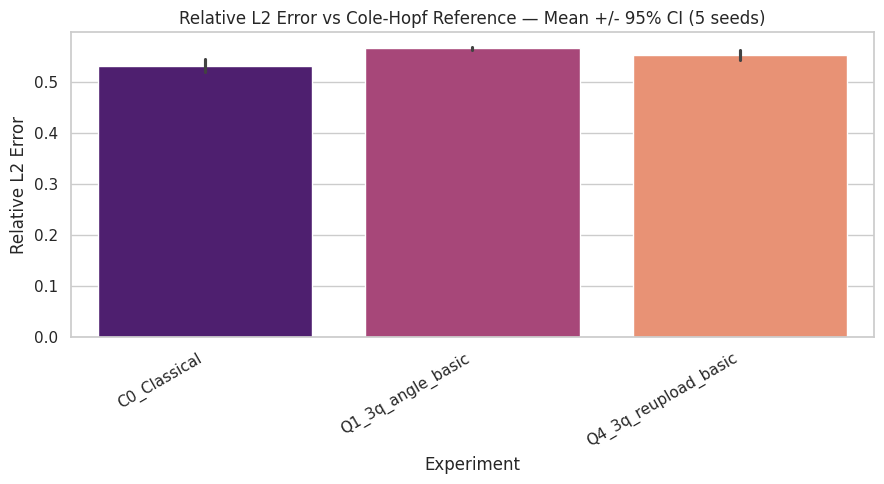


### SCIENTIFIC BENCHMARK MASTER TABLE (single-seed diagnostics, original 6-config matrix) ###


,Experiment,Qubits,Encoding,Ansatz,Params,Total_Loss,Time_sec,Max_Freq_k,Spectral_Bins,McClean_BP_Var,Spatial_Act_CV
0,C0_Classical,-,-,-,2051,0.085188,25.01,NaN,NaN,NaN,0.270894
1,Q1_3q_angle_basic,3,angle,basic_entangler,2283,0.077186,426.13,0.635347,5.0,0.258619,0.575080
2,Q2_4q_angle_basic,4,angle,basic_entangler,2345,0.053728,836.91,0.635347,5.0,0.034363,0.401501
3,Q3_5q_angle_basic,5,angle,basic_entangler,2407,0.043746,1897.85,0.953020,7.0,0.034518,0.284589
4,Q4_3q_reupload_basic,3,reupload,basic_entangler,2283,0.107096,569.71,1.111856,7.0,0.078976,0.222780
5,Q5_3q_angle_strong,3,angle,strongly_entangling,2307,0.020025,366.38,0.476510,4.0,0.083585,0.343272



### Statistical Comparison vs Classical C0 (Welch's t-test, RelL2) ###
Uncorrected alpha = 0.05 | Bonferroni-corrected alpha = 0.0100 (for 5 simultaneous comparisons)
Q1_3q_angle_basic        | p = 0.0092 | uncorrected: Significant      | Bonferroni-corrected: Significant
Q2_4q_angle_basic        | p = nan | uncorrected: Not Significant  | Bonferroni-corrected: Not Significant
Q3_5q_angle_basic        | p = nan | uncorrected: Not Significant  | Bonferroni-corrected: Not Significant
Q4_3q_reupload_basic     | p = 0.0564 | uncorrected: Not Significant  | Bonferroni-corrected: Not Significant
Q5_3q_angle_strong       | p = nan | uncorrected: Not Significant  | Bonferroni-corrected: Not Significant


/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


,Experiment,p_value,Significant_Uncorrected,Significant_Bonferroni
0,Q1_3q_angle_basic,0.009172,Significant,Significant
1,Q2_4q_angle_basic,NaN,Not Significant,Not Significant
2,Q3_5q_angle_basic,NaN,Not Significant,Not Significant
3,Q4_3q_reupload_basic,0.056450,Not Significant,Not Significant
4,Q5_3q_angle_strong,NaN,Not Significant,Not Significant


In [ ]:
TARGET_SEEDS = [11, 29, 47, 71, 97]

def run_multi_seed_experiment(experiments, target_seeds):
    all_results = []
    print(f"Running {len(experiments)} experiments over {len(target_seeds)} seeds...")

    # Reference solution is deterministic and independent of model training
    x_torch, t_torch, _, _, u_reference = get_reference_solution()

    for seed in target_seeds:
        print(f"\n--- Running with SEED: {seed} ---")
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        for exp_cfg in experiments:
            print(f"  Experiment: {exp_cfg['name']}")
            run_result = run_experiment(exp_cfg, epochs=500)
            model = run_result["model"]

            mse, l2_rel, max_err = calculate_metrics(model, x_torch, t_torch, u_reference)

            all_results.append({
                "Seed": seed,
                "Experiment": exp_cfg["name"],
                "Qubits": exp_cfg.get("n_qubits", "-"),
                "Encoding": exp_cfg.get("encoding", "-"),
                "Ansatz": exp_cfg.get("ansatz", "-"),
                "Params": model.num_params(),
                "Final_Loss": run_result["final_loss"],
                "Time_s": run_result["time_s"],
                "RelL2": l2_rel,
                "MaxErr": max_err,
                "PDE_Loss_Final": run_result["history"]["pde"][-1],
            })

    return pd.DataFrame(all_results)


# ------------------------------------------------------------
# 1. Execute Multi-Seed Statistical Data Collection
# ------------------------------------------------------------
print("Starting multi-seed experiment loop...")

RUN_STAGE_C = True # Set to True to only run C0, Q1, and Q2 for Stage C

if RUN_STAGE_C:
    filtered_experiments = [
        exp for exp in EXPERIMENTS
        if exp['name'] in ['C0_Classical', 'Q1_3q_angle_basic', 'Q4_3q_reupload_basic']
    ]
    multi_seed_df = run_multi_seed_experiment(filtered_experiments, TARGET_SEEDS)
else:
    multi_seed_df = run_multi_seed_experiment(EXPERIMENTS, TARGET_SEEDS)

multi_seed_df.to_csv("stage_c_statistical_data.csv", index=False)

# ------------------------------------------------------------
# 2. NEW: Mean / Std / 95% CI summary per experiment
# (previously missing — multi_seed_df alone only has one row per
# seed x experiment; this aggregates it into the mean +/- 95% CI
# table needed to actually report result stability, per Decision
# Rule #6.)
# ------------------------------------------------------------
from scipy import stats as scipy_stats

def summarize_with_ci(df, group_col, value_col, confidence=0.95):
    rows = []
    for name, g in df.groupby(group_col):
        vals = g[value_col].values
        n = len(vals)
        mean = vals.mean()
        std = vals.std(ddof=1) if n > 1 else 0.0
        if n > 1:
            sem = std / np.sqrt(n)
            ci_half = sem * scipy_stats.t.ppf((1 + confidence) / 2, n - 1)
        else:
            ci_half = 0.0
        rows.append({
            group_col: name, "N_seeds": n, "Mean": mean, "Std": std,
            "CI95_Lower": mean - ci_half, "CI95_Upper": mean + ci_half,
        })
    return pd.DataFrame(rows)

rel_l2_summary = summarize_with_ci(multi_seed_df, "Experiment", "RelL2")
print("\n--- Stage C: Relative L2 Error, mean +/- 95% CI across 5 seeds ---")
print(rel_l2_summary.to_string(index=False))

plt.figure(figsize=(9, 5))
sns.barplot(data=multi_seed_df, x="Experiment", y="RelL2", hue="Experiment",
            palette="magma", legend=False, errorbar=("ci", 95))
plt.title("Relative L2 Error vs Cole-Hopf Reference — Mean +/- 95% CI (5 seeds)")
plt.ylabel("Relative L2 Error")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("stage_c_rel_l2_ci.png", dpi=150)
plt.show()

# ------------------------------------------------------------
# 3. Scientific Benchmark Master Table (single-seed diagnostics)
# NOTE: Params/Total_Loss/Time and the XAI columns (Fourier,
# McClean, activation) below are from the single official
# SEED=42 run — kept separate from the multi-seed RelL2 table
# above, so single-seed diagnostics are never implied to be
# multi-seed averaged.
# ------------------------------------------------------------
master_report = summary_df[summary_df["Experiment"] != "C0_Best_Classical"].copy()
master_report = master_report.merge(fourier_df[['Experiment', 'MaxSignificantFreq', 'SignificantBins']], on='Experiment', how='left')
master_report = master_report.merge(mcclean_df[['Experiment', 'McClean_Variance']], on='Experiment', how='left')
master_report = master_report.merge(activation_df[['Experiment', 'CoeffOfVariation']], on='Experiment', how='left')

master_report.columns = [
    'Experiment', 'Qubits', 'Encoding', 'Ansatz', 'Params',
    'Total_Loss', 'Time_sec', 'Max_Freq_k', 'Spectral_Bins',
    'McClean_BP_Var', 'Spatial_Act_CV'
]

print("\n### SCIENTIFIC BENCHMARK MASTER TABLE (single-seed diagnostics, original 6-config matrix) ###")
display(master_report)
master_report.to_csv("qapinn_scientific_deliverables.csv", index=False)

# ------------------------------------------------------------
# 4. Statistical Significance — Welch's t-test (unequal variance)
# + Bonferroni-corrected threshold for 5 simultaneous comparisons.
# ------------------------------------------------------------
from scipy.stats import ttest_ind

n_comparisons = len([m for m in EXPERIMENTS if m['kind'] == 'qapinn'])
bonferroni_alpha = 0.05 / n_comparisons

print("\n### Statistical Comparison vs Classical C0 (Welch's t-test, RelL2) ###")
print(f"Uncorrected alpha = 0.05 | Bonferroni-corrected alpha = {bonferroni_alpha:.4f} "
      f"(for {n_comparisons} simultaneous comparisons)")

c0_scores = multi_seed_df[multi_seed_df['Experiment'] == 'C0_Classical']['RelL2'].values

sig_results = []
for model_name in [m['name'] for m in EXPERIMENTS if m['kind'] == 'qapinn']:
    q_scores = multi_seed_df[multi_seed_df['Experiment'] == model_name]['RelL2'].values
    t_stat, p_val = ttest_ind(c0_scores, q_scores, equal_var=False)
    uncorrected = "Significant" if p_val < 0.05 else "Not Significant"
    corrected = "Significant" if p_val < bonferroni_alpha else "Not Significant"
    print(f"{model_name:24s} | p = {p_val:.4f} | uncorrected: {uncorrected:16s} | Bonferroni-corrected: {corrected}")
    sig_results.append({"Experiment": model_name, "p_value": p_val,
                         "Significant_Uncorrected": uncorrected, "Significant_Bonferroni": corrected})

significance_df = pd.DataFrame(sig_results)
significance_df

In [ ]:
# ============================================================
# Stage C continuation — complete Q2, Q3, Q5 (skipped above),
# merge with the already-completed C0/Q1/Q4 results.
# ============================================================
remaining_names = ['Q2_4q_angle_basic', 'Q3_5q_angle_basic', 'Q5_3q_angle_strong']
remaining_experiments = [exp for exp in EXPERIMENTS if exp['name'] in remaining_names]

multi_seed_df_extra = run_multi_seed_experiment(remaining_experiments, TARGET_SEEDS)
multi_seed_df = pd.concat([multi_seed_df, multi_seed_df_extra], ignore_index=True)
multi_seed_df.to_csv("stage_c_statistical_data.csv", index=False)

rel_l2_summary = summarize_with_ci(multi_seed_df, "Experiment", "RelL2")
print("\n--- Stage C (complete): Relative L2 Error, mean +/- 95% CI across 5 seeds ---")
print(rel_l2_summary.to_string(index=False))

plt.figure(figsize=(9, 5))
sns.barplot(data=multi_seed_df, x="Experiment", y="RelL2", hue="Experiment",
            palette="magma", legend=False, errorbar=("ci", 95))
plt.title("Relative L2 Error vs Cole-Hopf Reference — Mean +/- 95% CI (5 seeds, complete)")
plt.ylabel("Relative L2 Error"); plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.savefig("stage_c_rel_l2_ci_complete.png", dpi=150); plt.show()

from scipy.stats import ttest_ind
n_comparisons = len([m for m in EXPERIMENTS if m['kind'] == 'qapinn'])
bonferroni_alpha = 0.05 / n_comparisons
c0_scores = multi_seed_df[multi_seed_df['Experiment'] == 'C0_Classical']['RelL2'].values

print(f"\n### Statistical Comparison vs Classical C0 — complete 6-config matrix ###")
print(f"Uncorrected alpha = 0.05 | Bonferroni-corrected alpha = {bonferroni_alpha:.4f}")
sig_results = []
for model_name in [m['name'] for m in EXPERIMENTS if m['kind'] == 'qapinn']:
    q_scores = multi_seed_df[multi_seed_df['Experiment'] == model_name]['RelL2'].values
    t_stat, p_val = ttest_ind(c0_scores, q_scores, equal_var=False)
    uncorrected = "Significant" if p_val < 0.05 else "Not Significant"
    corrected = "Significant" if p_val < bonferroni_alpha else "Not Significant"
    print(f"{model_name:24s} | p = {p_val:.4f} | uncorrected: {uncorrected:16s} | Bonferroni-corrected: {corrected}")
    sig_results.append({"Experiment": model_name, "p_value": p_val,
                         "Significant_Uncorrected": uncorrected, "Significant_Bonferroni": corrected})
significance_df = pd.DataFrame(sig_results)

Running 3 experiments over 5 seeds...
get_reference_solution() returning 5 values.

--- Running with SEED: 11 ---
  Experiment: Q2_4q_angle_basic
Running Q2_4q_angle_basic
[   0.7s] Epoch     1/500 | total=0.662603 | grad_var=2.15e-03 | q_var=1.97e-04
[   5.0s] Epoch    10/500 | total=0.461166 | grad_var=1.64e-04 | q_var=2.69e-06
[   9.2s] Epoch    20/500 | total=0.581599 | grad_var=8.29e-06 | q_var=2.36e-06
[  13.4s] Epoch    30/500 | total=0.480034 | grad_var=5.05e-06 | q_var=1.06e-05
[  17.0s] Epoch    40/500 | total=0.459905 | grad_var=7.38e-06 | q_var=1.97e-05
[  20.7s] Epoch    50/500 | total=0.457593 | grad_var=3.06e-05 | q_var=5.59e-05
[  25.4s] Epoch    60/500 | total=0.411549 | grad_var=8.42e-06 | q_var=1.49e-05
[  29.0s] Epoch    70/500 | total=0.378577 | grad_var=8.73e-06 | q_var=4.60e-05
[  32.6s] Epoch    80/500 | total=0.364432 | grad_var=3.77e-05 | q_var=2.01e-04
[  37.3s] Epoch    90/500 | total=0.305968 | grad_var=1.33e-04 | q_var=5.83e-04
[  40.9s] Epoch   100/500 | 

### Step 24: Spatial Error Distribution

Finally, we generate a pointwise error map comparing a selected model against the Cole-Hopf reference. This visualization helps pinpoint exactly where in the $(x, t)$ domain the model fails to capture the physics, such as around the steepening shock front.

In [ ]:
# Plotting the pointwise error for the most interesting variant (Q4 or Q3)
target_q = "Q3_5q_angle_basic"
model_q = results[target_q]["model"]

with torch.no_grad():
    u_q = model_q(x_torch, t_torch).cpu().numpy().reshape(XX.shape)
u_ref_plot = u_reference.numpy().reshape(XX.shape)
error_map = np.abs(u_ref_plot - u_q)

plt.figure(figsize=(8, 5))
plt.pcolormesh(TT, XX, error_map, cmap='inferno', shading='auto')
plt.colorbar(label='Absolute Error')
plt.title(f"Pointwise Error vs Cole-Hopf Reference: {target_q}")
plt.xlabel("t"); plt.ylabel("x")
plt.show()

**Reading the output:** look for *where* the error concentrates, not just its magnitude — errors clustering
near the shock front (around `x=0`, growing with `t`) indicate the model is struggling specifically with the
PDE's steepening nonlinear feature, which is a more specific and useful diagnosis than a single scalar error
number. Compare this map's pattern against that same configuration's activation map from earlier in the notebook
— a model whose activation map showed little x-dependence should show error concentrated in exactly the
x-varying regions it failed to represent.

### Notes

- **GPU usage**: classical baseline(s) and QAPINN's projection/post-processing layers train on CUDA. The
  variational quantum circuit executes on PennyLane's `default.qubit` CPU simulator — a library-level constraint,
  not a config choice.
- **TensorFlow**: not used.
- **Quantum backend**: the quantum circuit runs on PennyLane's JAX interface (`interface="jax"`, JIT-compiled via
  `jax.jit`/`jax.vmap`) instead of the torch interface, bridged into the PyTorch training loop through a small
  custom `torch.autograd.Function` (`JaxQuantumLayer`) that supports the multi-order differentiation a PINN needs
  (`u_xx`, then weight gradients through it). Verified against the original torch-interface circuit before this
  notebook was edited -- forward pass, `u_x`, `u_xx`, and weight gradients all matched to float32 precision across
  all five `Q1`-`Q5` configurations. Compiled circuits are cached per architecture, so Stage C's multi-seed sweep
  pays the JIT compile cost once per config, not once per seed. Everything else (PDE-residual autograd, the
  training loop, the optimizer) remains plain PyTorch.
- **Reproducibility scope**: the original 6-configuration matrix (`C0_Classical` + `Q1`–`Q5`) is run once at
  `SEED=42` for all single-seed diagnostics (loss curves, Fourier, McClean, activation maps), and separately
  re-run across 5 additional seeds in the Stage C section for statistical confirmation of `RelL2` accuracy.
  `C0_Best_Classical` is single-seed only, on a different (2000-epoch) training budget. State all of this
  explicitly in the report rather than implying uniform treatment across every number.
- **Known, now-fixed issue**: the McClean gradient-variance scan previously used an all-zero fixed input, which
  silently made `"angle"` and `"reupload"` encoding produce the identical circuit. Any `Q1`-vs-`Q4` McClean
  comparison from a notebook version prior to this one should be discarded, not merged with these corrected
  numbers.
- **Scope of this study**: validated on a single nonlinear PDE benchmark (viscous Burgers' equation). Extending
  the same six-configuration, three-technique XAI methodology to a second, contrasting benchmark (e.g. the linear
  heat equation) is a natural next step to test whether the barren-plateau and expressivity findings generalize
  beyond this specific problem — proposed here as **Future Work** rather than attempted in this notebook, given
  the scope and time already invested in doing the single-PDE analysis rigorously.

**Decision-rules reference** (used throughout this notebook's markdown, adapted from the project's investigation plan):

| Rule | Condition | Conclusion |
|---|---|---|
| 1 | QAPINN beats **both** classical baselines | Strong evidence for a useful quantum configuration |
| 2 | QAPINN beats only the parameter-matched classical baseline | Evidence for parameter efficiency, not best accuracy |
| 3 | Lower training loss but higher Rel L2 Error | Not a solution-quality win — investigate loss imbalance |
| 4 | Less accurate and slower | Report as a negative result, honestly |
| 5 | More qubits/depth help but cost grows fast | Report the accuracy-cost trade-off, not a free win |
| 6 | Large variation across seeds | Report as unstable/inconclusive |

**Report checklist** — evidence gathered in this notebook, mapped to typical report sections:

- *Experiments*: `summary_df` (Cell 7 + Classical-Best cell) — final loss, parameter count, training time.
- *Results (accuracy)*: Master Performance Table (single-seed) + Stage C `rel_l2_summary`/significance table
  (multi-seed) — both against the true Cole-Hopf reference.
- *Explainability §1 (expressivity)*: circuit-only Fourier spectrum, `fourier_df` (Cell 11).
- *Explainability §2 (trainability)*: corrected McClean scan (Cell 11), Q5 scale-robustness, 5-seed
  cross-config robustness check, quantum-only gradient variance plot, weight-movement check.
- *Explainability §3 (what was learned)*: activation maps + pointwise error map.
- *Limitations*: single-PDE scope, single-seed default for the diagnostic cells, Bonferroni caveat on Stage C
  significance, `C0_Best_Classical`'s different epoch budget, CPU/GPU training-time gap.
- *Future Work*: second-PDE extension (heat equation), Stage D-style qubit/depth scaling with full seed sweeps.